<a href="https://colab.research.google.com/github/jojomitra/satellite-orbit-classification/blob/main/Satellite_Orbit_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# CELL 1 — CHECK GOOGLE COLAB ENVIRONMENT
# ============================================================

import sys
import numpy as np
import pandas as pd
import sklearn
import matplotlib
import joblib
import requests
import matplotlib.pyplot as plt

print("Python version:")
print(sys.version)

print("\nPackage versions:")
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Joblib:", joblib.__version__)
print("Requests:", requests.__version__)

print("\nEnvironment check complete.")

Python version:
3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]

Package versions:
NumPy: 2.1.3
Pandas: 2.2.3
Scikit-learn: 1.6.1
Matplotlib: 3.10.0
Joblib: 1.6.0
Requests: 2.32.4

Environment check complete.


In [2]:
# ============================================================
# CELL 2 — PROJECT CONFIGURATION
# ============================================================

from pathlib import Path


# ============================================================
# GENERAL SETTINGS
# ============================================================

RANDOM_STATE = 42


# ============================================================
# LOCAL COLAB STORAGE
# ============================================================

BASE_DIR = Path(
    "/content"
)

LOCAL_PROJECT_DIR = (
    BASE_DIR
    / "satellite_project"
)

LOCAL_PROJECT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# GOOGLE DRIVE
# ============================================================
#
# Cell 3 will mount Google Drive and create the persistent
# CelesTrak storage structure.
# ============================================================

DRIVE_ROOT_NAME = (
    "CelesTrak_Active_Satellites"
)


# ============================================================
# INITIAL LOCAL DATASET LOCATION
# ============================================================

RAW_CSV = (
    LOCAL_PROJECT_DIR
    / "active_satellites_raw.csv"
)


# ============================================================
# CELESTRAK
# ============================================================

CELESTRAK_URL = (
    "https://celestrak.org/"
    "NORAD/elements/gp.php"
    "?GROUP=ACTIVE&FORMAT=CSV"
)


# ============================================================
# GITHUB CONFIGURATION
# ============================================================

GITHUB_OWNER = "jojomitra"

GITHUB_REPO = "satellite-orbit-classification"

GITHUB_BRANCH = "main"

GITHUB_SECRET_NAME = "GITHUB_TOKEN"


# ============================================================
# GITHUB API
# ============================================================

GITHUB_API_BASE = (
    "https://api.github.com"
)

GITHUB_API_VERSION = (
    "2026-03-10"
)


# ============================================================
# GITHUB FILE SIZE SAFETY LIMIT
# ============================================================

GITHUB_MAX_FILE_SIZE = (
    95 * 1024 * 1024
)


# ============================================================
# GITHUB REPOSITORY URL
# ============================================================

GITHUB_REPO_URL = (
    f"https://github.com/"
    f"{GITHUB_OWNER}/"
    f"{GITHUB_REPO}"
)


# ============================================================
# LOAD GITHUB TOKEN FROM COLAB SECRETS
# ============================================================

try:

    from google.colab import userdata

    GITHUB_TOKEN = userdata.get(
        GITHUB_SECRET_NAME
    )

except Exception as exc:

    raise RuntimeError(
        "Could not access the GITHUB_TOKEN Colab Secret.\n\n"
        "In Google Colab, click the key/Secrets icon on the "
        "left sidebar and create a secret named:\n\n"
        "GITHUB_TOKEN\n\n"
        "Then enable notebook access to that secret.\n\n"
        f"Original error: {exc}"
    )


if not GITHUB_TOKEN:

    raise RuntimeError(
        "GITHUB_TOKEN is empty.\n\n"
        "Please add your GitHub personal access token "
        "to Colab Secrets."
    )


print("=" * 70)
print("PROJECT CONFIGURATION")
print("=" * 70)

print(
    "\nGitHub repository:"
)

print(
    GITHUB_REPO_URL
)

print(
    "\nGitHub branch:",
    GITHUB_BRANCH
)

print(
    "\nRandom state:",
    RANDOM_STATE
)

print(
    "\nCelesTrak endpoint:"
)

print(
    CELESTRAK_URL
)

PROJECT CONFIGURATION

GitHub repository:
https://github.com/jojomitra/satellite-orbit-classification

GitHub branch: main

Random state: 42

CelesTrak endpoint:
https://celestrak.org/NORAD/elements/gp.php?GROUP=ACTIVE&FORMAT=CSV


In [3]:
# ============================================================
# CELL 3 — DAILY DATA CACHE + GOOGLE DRIVE + GITHUB
# ============================================================
#
# DAILY DATA BEHAVIOR
#
# Google Drive:
#
#   today's file exists
#       -> do NOT contact CelesTrak
#       -> use today's file
#
#   today's file does not exist
#       -> contact CelesTrak once
#       -> download latest Active Satellites CSV
#       -> validate it
#       -> save today's file to Google Drive
#       -> delete older daily raw CSVs from Drive
#
#
# GITHUB BEHAVIOR
#
#   datasets/active_satellites_YYYY-MM-DD.csv
#
#   The historical GitHub copy is NOT deleted.
#
#   Each experiment gets:
#
#   runs/YYYY-MM-DD/run_TIMESTAMP/
#
#   containing the complete results of that run.
#
# ============================================================


# ============================================================
# IMPORTS
# ============================================================

from google.colab import drive

from datetime import datetime, timezone
from zoneinfo import ZoneInfo

from pathlib import Path

import base64
import hashlib
import json
import shutil
import subprocess

import pandas as pd
import requests


# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================

print("=" * 70)
print("GOOGLE DRIVE")
print("=" * 70)

drive.mount(
    "/content/drive",
    force_remount=False
)

print(
    "\nGoogle Drive mounted."
)


# ============================================================
# 2. DEFINE DRIVE STRUCTURE
# ============================================================

DRIVE_DATA_DIR = (
    Path(
        "/content/drive/MyDrive"
    )
    / DRIVE_ROOT_NAME
)

DRIVE_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 3. UAE DATE/TIME
# ============================================================

UAE_TIMEZONE = ZoneInfo(
    "Asia/Dubai"
)

now_uae = datetime.now(
    UAE_TIMEZONE
)

TODAY_DATE = (
    now_uae.strftime("%Y-%m-%d")
)


# ============================================================
# 4. RUN ID
# ============================================================
#
# One Colab runtime/session gets one run ID unless Cell 3 is
# deliberately re-executed in a fresh runtime.
# ============================================================

if "RUN_ID" not in globals():

    RUN_ID = (
        now_uae.strftime(
            "%Y%m%d_%H%M%S_%f"
        )
    )


# ============================================================
# 5. DAILY DATASET PATHS
# ============================================================

TODAY_FILE = (
    DRIVE_DATA_DIR
    / f"active_satellites_{TODAY_DATE}.csv"
)


# ============================================================
# 6. RUN-SPECIFIC GOOGLE DRIVE DIRECTORIES
# ============================================================

RUN_DIR = (
    DRIVE_DATA_DIR
    / "runs"
    / TODAY_DATE
    / f"run_{RUN_ID}"
)

MODEL_DIR = (
    RUN_DIR
    / "models"
)

RESULT_DIR = (
    RUN_DIR
    / "results"
)

FIGURE_DIR = (
    RUN_DIR
    / "figures"
)


RUN_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 7. OUTPUT PATHS
# ============================================================

PROCESSED_CSV = (
    RUN_DIR
    / "active_satellites_with_orbit_class.csv"
)

RESULTS_CSV = (
    RESULT_DIR
    / "model_comparison.csv"
)

ABLATION_CSV = (
    RESULT_DIR
    / "ablation_results.csv"
)

METADATA_JSON = (
    RESULT_DIR
    / "experiment_metadata.json"
)

PROJECT_ZIP = (
    RUN_DIR
    / "experiment_bundle.zip"
)


# ============================================================
# 8. GITHUB PATHS
# ============================================================

GITHUB_DATASET_PATH = (
    "datasets/"
    f"active_satellites_{TODAY_DATE}.csv"
)

GITHUB_RUN_PREFIX = (
    "runs/"
    f"{TODAY_DATE}/"
    f"run_{RUN_ID}"
)


# ============================================================
# 9. GITHUB HEADERS
# ============================================================

GITHUB_HEADERS = {

    "Accept":
        "application/vnd.github+json",

    "Authorization":
        f"Bearer {GITHUB_TOKEN}",

    "X-GitHub-Api-Version":
        GITHUB_API_VERSION
}


# ============================================================
# 10. GITHUB API HELPER
# ============================================================

def github_api_request(
    method,
    endpoint,
    payload=None
):

    url = (
        f"{GITHUB_API_BASE}"
        f"{endpoint}"
    )


    response = requests.request(
        method=method,
        url=url,
        headers=GITHUB_HEADERS,
        json=payload,
        timeout=120
    )


    if not response.ok:

        raise RuntimeError(
            "GitHub API request failed.\n\n"
            f"Method: {method}\n"
            f"URL: {url}\n"
            f"Status: {response.status_code}\n\n"
            f"Response:\n"
            f"{response.text[:3000]}"
        )


    if response.text:

        return response.json()

    return None


# ============================================================
# 11. CHECK WHETHER A FILE ALREADY EXISTS ON GITHUB
# ============================================================

def github_file_exists(
    remote_path
):

    endpoint = (
        f"/repos/"
        f"{GITHUB_OWNER}/"
        f"{GITHUB_REPO}/"
        f"contents/"
        f"{remote_path}"
    )


    response = requests.get(
        f"{GITHUB_API_BASE}{endpoint}",
        headers=GITHUB_HEADERS,
        params={
            "ref": GITHUB_BRANCH
        },
        timeout=60
    )


    if response.status_code == 200:
        return True

    if response.status_code == 404:
        return False


    raise RuntimeError(
        "Could not determine whether the GitHub file "
        "already exists.\n\n"
        f"Status: {response.status_code}\n"
        f"Response: {response.text[:2000]}"
    )


# ============================================================
# 12. CREATE ONE GITHUB COMMIT CONTAINING MANY FILES
# ============================================================
#
# This uses GitHub's low-level Git database API:
#
#     branch ref
#        ↓
#     current commit
#        ↓
#     base tree
#        ↓
#     blobs
#        ↓
#     new tree
#        ↓
#     new commit
#        ↓
#     update branch
#
# Therefore one experiment run becomes one GitHub commit.
# ============================================================

def github_commit_files(
    local_remote_pairs,
    commit_message
):

    # --------------------------------------------------------
    # Safety check
    # --------------------------------------------------------

    if not local_remote_pairs:

        raise ValueError(
            "No files were provided for GitHub commit."
        )


    # --------------------------------------------------------
    # Check local files and file sizes
    # --------------------------------------------------------

    for local_path, remote_path in local_remote_pairs:

        local_path = Path(
            local_path
        )

        if not local_path.exists():

            raise FileNotFoundError(
                f"File does not exist:\n{local_path}"
            )


        file_size = (
            local_path.stat().st_size
        )


        if file_size > GITHUB_MAX_FILE_SIZE:

            size_mb = (
                file_size
                / 1024
                / 1024
            )

            raise RuntimeError(
                "A file is too large for the GitHub "
                "regular-repository workflow.\n\n"
                f"File: {local_path}\n"
                f"Size: {size_mb:.2f} MiB\n\n"
                "GitHub blocks files larger than 100 MiB. "
                "Use Git LFS or external object storage "
                "for files of this size."
            )


    # --------------------------------------------------------
    # Get current branch reference
    # --------------------------------------------------------

    ref_endpoint = (
        f"/repos/"
        f"{GITHUB_OWNER}/"
        f"{GITHUB_REPO}/"
        f"git/ref/heads/"
        f"{GITHUB_BRANCH}"
    )


    ref_data = github_api_request(
        "GET",
        ref_endpoint
    )


    parent_commit_sha = (
        ref_data["object"]["sha"]
    )


    # --------------------------------------------------------
    # Get current commit to determine its tree
    # --------------------------------------------------------

    commit_endpoint = (
        f"/repos/"
        f"{GITHUB_OWNER}/"
        f"{GITHUB_REPO}/"
        f"git/commits/"
        f"{parent_commit_sha}"
    )


    parent_commit = github_api_request(
        "GET",
        commit_endpoint
    )


    base_tree_sha = (
        parent_commit["tree"]["sha"]
    )


    # --------------------------------------------------------
    # Create Git blobs
    # --------------------------------------------------------

    tree_entries = []


    print(
        "\nCreating GitHub blobs..."
    )


    for local_path, remote_path in local_remote_pairs:

        local_path = Path(
            local_path
        )


        file_bytes = (
            local_path.read_bytes()
        )


        encoded_content = (
            base64.b64encode(
                file_bytes
            )
            .decode("ascii")
        )


        blob_endpoint = (
            f"/repos/"
            f"{GITHUB_OWNER}/"
            f"{GITHUB_REPO}/"
            f"git/blobs"
        )


        blob_data = github_api_request(
            "POST",
            blob_endpoint,
            {
                "content":
                    encoded_content,

                "encoding":
                    "base64"
            }
        )


        tree_entries.append({
            "path":
                remote_path,

            "mode":
                "100644",

            "type":
                "blob",

            "sha":
                blob_data["sha"]
        })


        print(
            f"  ✓ {remote_path}"
        )


    # --------------------------------------------------------
    # Create new tree
    # --------------------------------------------------------

    tree_endpoint = (
        f"/repos/"
        f"{GITHUB_OWNER}/"
        f"{GITHUB_REPO}/"
        f"git/trees"
    )


    tree_data = github_api_request(
        "POST",
        tree_endpoint,
        {
            "base_tree":
                base_tree_sha,

            "tree":
                tree_entries
        }
    )


    new_tree_sha = (
        tree_data["sha"]
    )


    # --------------------------------------------------------
    # Create commit
    # --------------------------------------------------------

    create_commit_endpoint = (
        f"/repos/"
        f"{GITHUB_OWNER}/"
        f"{GITHUB_REPO}/"
        f"git/commits"
    )


    new_commit = github_api_request(
        "POST",
        create_commit_endpoint,
        {
            "message":
                commit_message,

            "tree":
                new_tree_sha,

            "parents":
                [parent_commit_sha]
        }
    )


    new_commit_sha = (
        new_commit["sha"]
    )


    # --------------------------------------------------------
    # Update branch
    # --------------------------------------------------------

    update_ref_endpoint = (
        f"/repos/"
        f"{GITHUB_OWNER}/"
        f"{GITHUB_REPO}/"
        f"git/refs/heads/"
        f"{GITHUB_BRANCH}"
    )


    github_api_request(
        "PATCH",
        update_ref_endpoint,
        {
            "sha":
                new_commit_sha,

            "force":
                False
        }
    )


    commit_url = (
        f"{GITHUB_REPO_URL}"
        f"/commit/"
        f"{new_commit_sha}"
    )


    print(
        "\nGitHub commit created:"
    )

    print(
        commit_url
    )


    return {
        "commit_sha":
            new_commit_sha,

        "commit_url":
            commit_url
    }


# ============================================================
# 13. DAILY CELESTRAK DATA VALIDATION
# ============================================================

REQUIRED_COLUMNS = [
    "OBJECT_NAME",
    "OBJECT_ID",
    "EPOCH",
    "MEAN_MOTION",
    "ECCENTRICITY",
    "INCLINATION",
    "RA_OF_ASC_NODE",
    "ARG_OF_PERICENTER",
    "MEAN_ANOMALY",
    "NORAD_CAT_ID"
]


def validate_active_satellites_csv(
    path
):

    try:

        test_df = pd.read_csv(
            path
        )

    except Exception as exc:

        raise RuntimeError(
            "The file could not be read as CSV.\n\n"
            f"Error: {exc}"
        )


    if len(test_df) == 0:

        raise RuntimeError(
            "The Active Satellites CSV contains zero rows."
        )


    normalized_columns = [
        str(col).strip().upper()
        for col in test_df.columns
    ]


    missing_columns = [
        col
        for col in REQUIRED_COLUMNS
        if col not in normalized_columns
    ]


    if missing_columns:

        raise RuntimeError(
            "The CSV is missing expected CelesTrak "
            f"columns:\n{missing_columns}"
        )


    return test_df


# ============================================================
# 14. CHECK GOOGLE DRIVE FOR TODAY'S DATASET
# ============================================================

print("=" * 70)
print("DAILY CELESTRAK DATASET")
print("=" * 70)

print(
    "\nToday's UAE date:",
    TODAY_DATE
)

print(
    "\nGoogle Drive expected file:"
)

print(
    TODAY_FILE
)


if TODAY_FILE.exists():

    # ========================================================
    # TODAY'S FILE ALREADY EXISTS
    # ========================================================

    print(
        "\nToday's file already exists on Google Drive."
    )

    print(
        "CelesTrak will NOT be contacted."
    )


    df_today = validate_active_satellites_csv(
        TODAY_FILE
    )


else:

    # ========================================================
    # NEED TODAY'S DATASET
    # ========================================================

    print(
        "\nToday's file does not exist."
    )

    print(
        "Contacting CelesTrak once."
    )


    TEMP_CSV = (
        LOCAL_PROJECT_DIR
        / "active_satellites_download.tmp"
    )

    TEMP_CSV.unlink(
        missing_ok=True
    )


    command = [
        "curl",

        "-4",

        "-L",

        "--connect-timeout",
        "30",

        "--max-time",
        "180",

        "-sS",

        "-A",
        "Mozilla/5.0",

        "-H",
        "Cache-Control: no-cache",

        "-H",
        "Pragma: no-cache",

        "-o",
        str(TEMP_CSV),

        "-w",
        "%{http_code}",

        CELESTRAK_URL
    ]


    result = subprocess.run(
        command,
        capture_output=True,
        text=True
    )


    http_status = (
        result.stdout.strip()
    )


    if (
        result.returncode != 0
        or http_status != "200"
        or not TEMP_CSV.exists()
    ):

        TEMP_CSV.unlink(
            missing_ok=True
        )


        raise RuntimeError(
            "CelesTrak download failed.\n\n"
            f"curl return code: "
            f"{result.returncode}\n"
            f"HTTP status: "
            f"{http_status or 'NONE'}\n\n"
            f"Details:\n"
            f"{result.stderr[:2000]}"
        )


    # --------------------------------------------------------
    # Validate before modifying Drive
    # --------------------------------------------------------

    df_today = (
        validate_active_satellites_csv(
            TEMP_CSV
        )
    )


    # --------------------------------------------------------
    # Save today's dated file to Drive
    # --------------------------------------------------------

    shutil.copy2(
        TEMP_CSV,
        TODAY_FILE
    )


    TEMP_CSV.unlink(
        missing_ok=True
    )


    # --------------------------------------------------------
    # Delete previous dated raw files from Drive ONLY
    #
    # Do not delete:
    #   runs/
    #   models/
    #   results/
    #   anything else
    # --------------------------------------------------------

    deleted_old_files = 0


    for old_file in DRIVE_DATA_DIR.glob(
        "active_satellites_*.csv"
    ):

        if (
            old_file.resolve()
            == TODAY_FILE.resolve()
        ):
            continue


        old_file.unlink()

        deleted_old_files += 1


    print(
        "\nNew daily snapshot saved:"
    )

    print(
        TODAY_FILE
    )

    print(
        "\nOlder raw Drive snapshots deleted:",
        deleted_old_files
    )


# ============================================================
# 15. COPY DAILY DATASET TO LOCAL COLAB STORAGE
# ============================================================

shutil.copy2(
    TODAY_FILE,
    RAW_CSV
)


# ============================================================
# 16. DATA HASH
# ============================================================

DATA_SHA256 = hashlib.sha256(
    TODAY_FILE.read_bytes()
).hexdigest()


print(
    "\nRows in today's dataset:",
    f"{len(df_today):,}"
)

print(
    "\nSHA-256:"
)

print(
    DATA_SHA256
)


# ============================================================
# 17. UPLOAD DAILY DATASET TO GITHUB IF NECESSARY
# ============================================================
#
# IMPORTANT:
# Google Drive keeps only today's raw snapshot.
#
# GitHub keeps historical daily snapshots.
# ============================================================

if github_file_exists(
    GITHUB_DATASET_PATH
):

    print(
        "\nGitHub already contains today's dataset:"
    )

    print(
        GITHUB_DATASET_PATH
    )

    GITHUB_DATASET_COMMIT_URL = None


else:

    print(
        "\nUploading today's dataset to GitHub..."
    )


    dataset_commit = (
        github_commit_files(
            [
                (
                    TODAY_FILE,
                    GITHUB_DATASET_PATH
                )
            ],
            (
                "data: add CelesTrak Active "
                f"Satellites snapshot {TODAY_DATE}"
            )
        )
    )


    GITHUB_DATASET_COMMIT_URL = (
        dataset_commit["commit_url"]
    )


# ============================================================
# 18. FINAL RUN INFORMATION
# ============================================================

print("\n" + "=" * 70)
print("RUN CONFIGURATION")
print("=" * 70)

print(
    "\nRun ID:"
)

print(
    RUN_ID
)

print(
    "\nRun folder on Google Drive:"
)

print(
    RUN_DIR
)

print(
    "\nGitHub run folder:"
)

print(
    GITHUB_RUN_PREFIX
)

print(
    "\nToday's raw dataset on GitHub:"
)

print(
    f"{GITHUB_REPO_URL}/blob/"
    f"{GITHUB_BRANCH}/"
    f"{GITHUB_DATASET_PATH}"
)

GOOGLE DRIVE
Mounted at /content/drive

Google Drive mounted.
DAILY CELESTRAK DATASET

Today's UAE date: 2026-10-04

Google Drive expected file:
/content/drive/MyDrive/CelesTrak_Active_Satellites/active_satellites_2026-10-04.csv

Today's file already exists on Google Drive.
CelesTrak will NOT be contacted.

Rows in today's dataset: 16,633

SHA-256:
c671f57164705a63c529d3e7caaea341c5e108bfa7759d84eee9fb88bb040cfe

GitHub already contains today's dataset:
datasets/active_satellites_2026-10-04.csv

RUN CONFIGURATION

Run ID:
20261004_211451_853876

Run folder on Google Drive:
/content/drive/MyDrive/CelesTrak_Active_Satellites/runs/2026-10-04/run_20261004_211451_853876

GitHub run folder:
runs/2026-10-04/run_20261004_211451_853876

Today's raw dataset on GitHub:
https://github.com/jojomitra/satellite-orbit-classification/blob/main/datasets/active_satellites_2026-10-04.csv


In [4]:
# ============================================================
# CELL 4 — LOAD DATASET
# ============================================================

df_raw = pd.read_csv(RAW_CSV)

# Normalize column names
df_raw.columns = [
    str(col).strip().upper()
    for col in df_raw.columns
]

print("Raw dataset loaded successfully.\n")

print("Number of rows:", len(df_raw))
print("Number of columns:", len(df_raw.columns))

print("\nColumns:")
for col in df_raw.columns:
    print(" -", col)

print("\nFirst five rows:")
display(df_raw.head())

Raw dataset loaded successfully.

Number of rows: 16633
Number of columns: 17

Columns:
 - OBJECT_NAME
 - OBJECT_ID
 - EPOCH
 - MEAN_MOTION
 - ECCENTRICITY
 - INCLINATION
 - RA_OF_ASC_NODE
 - ARG_OF_PERICENTER
 - MEAN_ANOMALY
 - EPHEMERIS_TYPE
 - CLASSIFICATION_TYPE
 - NORAD_CAT_ID
 - ELEMENT_SET_NO
 - REV_AT_EPOCH
 - BSTAR
 - MEAN_MOTION_DOT
 - MEAN_MOTION_DDOT

First five rows:


,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,CLASSIFICATION_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT
0,CALSPHERE 1,1964-063C,2026-10-03T22:06:33.498720,13.767200,0.002474,90.2193,74.2860,326.2551,198.1062,0,U,900,999,8638,0.000435,4.370000e-06,0.0
1,CALSPHERE 2,1964-063E,2026-10-03T23:41:15.885888,13.529072,0.001666,90.2302,78.3486,271.7302,217.2708,0,U,902,999,87097,0.000087,6.600000e-07,0.0
2,LCS 1,1965-034C,2026-10-03T17:20:53.422656,9.893110,0.001096,32.1415,279.3294,148.4825,211.6331,0,U,1361,999,22063,0.000700,1.400000e-07,0.0
3,TEMPSAT 1,1965-065E,2026-10-03T06:34:22.215072,13.335995,0.006824,90.0096,212.6278,306.2480,210.0823,0,U,1512,999,97445,0.000079,4.800000e-07,0.0
4,CALSPHERE 4A,1965-065H,2026-10-03T20:42:20.018016,13.362936,0.007030,89.8869,121.3776,155.5044,217.2472,0,U,1520,999,97722,0.000118,7.100000e-07,0.0


In [5]:
# ============================================================
# CELL 5 — DATASET QUALITY REPORT
# ============================================================

print("=" * 70)
print("DATASET SIZE")
print("=" * 70)

print(f"Rows:    {df_raw.shape[0]:,}")
print(f"Columns: {df_raw.shape[1]:,}")


print("\n" + "=" * 70)
print("MISSING VALUES")
print("=" * 70)

missing = (
    df_raw.isna()
    .sum()
    .sort_values(ascending=False)
)

missing_nonzero = missing[
    missing > 0
]

if len(missing_nonzero) == 0:
    print("No missing values found.")
else:
    display(
        missing_nonzero.to_frame(
            name="Missing Count"
        )
    )


print("\n" + "=" * 70)
print("DUPLICATE ROWS")
print("=" * 70)

print(
    "Complete duplicate rows:",
    df_raw.duplicated().sum()
)


print("\n" + "=" * 70)
print("DUPLICATE NORAD IDs")
print("=" * 70)

if "NORAD_CAT_ID" in df_raw.columns:

    duplicate_ids = (
        df_raw["NORAD_CAT_ID"]
        .duplicated()
        .sum()
    )

    print(
        "Duplicate NORAD catalog IDs:",
        duplicate_ids
    )

DATASET SIZE
Rows:    16,633
Columns: 17

MISSING VALUES
No missing values found.

DUPLICATE ROWS
Complete duplicate rows: 0

DUPLICATE NORAD IDs
Duplicate NORAD catalog IDs: 0


In [6]:
# ============================================================
# CELL 6 — CLEAN DATA
# ============================================================

df = df_raw.copy()

NUMERIC_COLUMNS = [
    "MEAN_MOTION",
    "ECCENTRICITY",
    "INCLINATION",
    "RA_OF_ASC_NODE",
    "ARG_OF_PERICENTER",
    "MEAN_ANOMALY",
    "BSTAR",
    "MEAN_MOTION_DOT",
    "MEAN_MOTION_DDOT",
]

for col in NUMERIC_COLUMNS:

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


# ------------------------------------------------------------
# Remove duplicate satellites
# ------------------------------------------------------------

before = len(df)

df = df.drop_duplicates(
    subset="NORAD_CAT_ID",
    keep="first"
).copy()

print(
    "Duplicate NORAD entries removed:",
    before - len(df)
)


# ------------------------------------------------------------
# Remove impossible / unusable orbital records
# ------------------------------------------------------------

before = len(df)

df = df[
    df["MEAN_MOTION"].notna()
    & (df["MEAN_MOTION"] > 0)
].copy()

df = df[
    df["ECCENTRICITY"].notna()
    & (df["ECCENTRICITY"] >= 0)
    & (df["ECCENTRICITY"] < 1)
].copy()

df = df[
    df["INCLINATION"].notna()
    & (df["INCLINATION"] >= 0)
    & (df["INCLINATION"] <= 180)
].copy()

print(
    "Invalid/incomplete orbital rows removed:",
    before - len(df)
)


print("\nClean dataset shape:")
print(df.shape)

Duplicate NORAD entries removed: 0
Invalid/incomplete orbital rows removed: 0

Clean dataset shape:
(16633, 17)


In [7]:
# ============================================================
# CELL 7 — CALCULATE ORBITAL QUANTITIES
# ============================================================
#
# We derive:
#
#   1. Semi-major axis
#   2. Perigee radius
#   3. Apogee radius
#   4. Perigee altitude
#   5. Apogee altitude
#   6. Orbital period
#
# These quantities are derived from the CelesTrak GP fields:
#
#   MEAN_MOTION
#   ECCENTRICITY
#
# and are used to apply the ESA-based orbital-regime
# definitions in Cell 8.
#
# IMPORTANT:
# These derived quantities are used ONLY to construct
# ORBIT_CLASS. They remain excluded from ML predictors.
# ============================================================


# ============================================================
# CONSTANTS
# ============================================================

# Earth's standard gravitational parameter:
# km^3 / s^2

MU_EARTH_KM3_S2 = 398600.4418


# Earth's mean/equatorial radius used for altitude conversion:
# km

EARTH_RADIUS_KM = 6378.137


# Seconds in one day

SECONDS_PER_DAY = 86400.0


# Minutes in one day

MINUTES_PER_DAY = 1440.0


# ============================================================
# 1. MEAN MOTION → ANGULAR VELOCITY
# ============================================================
#
# CelesTrak MEAN_MOTION:
#     revolutions/day
#
# Convert to:
#     radians/second
# ============================================================

df["MEAN_MOTION_RAD_S"] = (
    df["MEAN_MOTION"]
    * 2.0
    * np.pi
    / SECONDS_PER_DAY
)


# ============================================================
# 2. SEMI-MAJOR AXIS
# ============================================================
#
# From Kepler's third law:
#
#     a = (mu / n^2)^(1/3)
#
# where:
#
#     mu = Earth's gravitational parameter
#     n  = mean motion in radians/second
# ============================================================

df["SEMI_MAJOR_AXIS_KM"] = (
    MU_EARTH_KM3_S2
    / (
        df["MEAN_MOTION_RAD_S"] ** 2
    )
) ** (1.0 / 3.0)


# ============================================================
# 3. PERIGEE RADIUS
# ============================================================
#
#     rp = a(1 - e)
# ============================================================

df["PERIGEE_RADIUS_KM"] = (
    df["SEMI_MAJOR_AXIS_KM"]
    * (
        1.0
        - df["ECCENTRICITY"]
    )
)


# ============================================================
# 4. APOGEE RADIUS
# ============================================================
#
#     ra = a(1 + e)
# ============================================================

df["APOGEE_RADIUS_KM"] = (
    df["SEMI_MAJOR_AXIS_KM"]
    * (
        1.0
        + df["ECCENTRICITY"]
    )
)


# ============================================================
# 5. PERIGEE ALTITUDE
# ============================================================

df["PERIGEE_ALT_KM"] = (
    df["PERIGEE_RADIUS_KM"]
    - EARTH_RADIUS_KM
)


# ============================================================
# 6. APOGEE ALTITUDE
# ============================================================

df["APOGEE_ALT_KM"] = (
    df["APOGEE_RADIUS_KM"]
    - EARTH_RADIUS_KM
)


# ============================================================
# 7. ORBITAL PERIOD
# ============================================================
#
# Mean motion = revolutions/day
#
# Therefore:
#
#     period (minutes) = 1440 / mean motion
# ============================================================

df["ORBITAL_PERIOD_MIN"] = (
    MINUTES_PER_DAY
    / df["MEAN_MOTION"]
)


df["ORBITAL_PERIOD_HOURS"] = (
    df["ORBITAL_PERIOD_MIN"]
    / 60.0
)


# ============================================================
# 8. SANITY CHECK
# ============================================================

print("=" * 70)
print("CALCULATED ORBITAL QUANTITIES")
print("=" * 70)


display(
    df[
        [
            "OBJECT_NAME",
            "MEAN_MOTION",
            "ECCENTRICITY",
            "INCLINATION",
            "SEMI_MAJOR_AXIS_KM",
            "PERIGEE_ALT_KM",
            "APOGEE_ALT_KM",
            "ORBITAL_PERIOD_MIN",
            "ORBITAL_PERIOD_HOURS"
        ]
    ].head(10)
)


print(
    "\nMinimum perigee altitude:",
    f"{df['PERIGEE_ALT_KM'].min():.2f} km"
)

print(
    "Maximum apogee altitude:",
    f"{df['APOGEE_ALT_KM'].max():.2f} km"
)

print(
    "\nOrbital quantity calculation complete."
)

CALCULATED ORBITAL QUANTITIES


,OBJECT_NAME,MEAN_MOTION,ECCENTRICITY,INCLINATION,SEMI_MAJOR_AXIS_KM,PERIGEE_ALT_KM,APOGEE_ALT_KM,ORBITAL_PERIOD_MIN,ORBITAL_PERIOD_HOURS
0,CALSPHERE 1,13.767200,0.002474,90.2193,7353.680679,957.348025,993.739332,104.596435,1.743274
1,CALSPHERE 2,13.529072,0.001666,90.2302,7439.718551,1049.187352,1073.975751,106.437457,1.773958
2,LCS 1,9.893110,0.001096,32.1415,9166.002252,2777.817388,2797.913115,145.555852,2.425931
3,TEMPSAT 1,13.335995,0.006824,90.0096,7511.353897,1081.957691,1184.476104,107.978444,1.799641
4,CALSPHERE 4A,13.362936,0.007030,89.8869,7501.254755,1070.387610,1175.847900,107.760749,1.796012
5,OPS 5712 (P/L 160),14.788803,0.000339,69.9148,7010.997625,630.481653,635.239597,97.370962,1.622849
6,LES-5,1.094254,0.005248,2.8683,39779.221831,33192.326259,33609.843403,1315.964443,21.932741
7,SURCAL 159,13.996232,0.000845,69.9723,7273.237340,888.951545,901.249135,102.884836,1.714747
8,OPS 5712 (P/L 153),13.968411,0.000532,69.9724,7282.891617,900.879172,908.630062,103.089753,1.718163
9,RIGIDSPHERE 2 (LCS 4),14.379695,0.005802,87.6179,7143.352249,723.769734,806.660764,100.141209,1.669020



Minimum perigee altitude: 134.74 km
Maximum apogee altitude: 364454.71 km

Orbital quantity calculation complete.


In [8]:
# ============================================================
# CELL 8 — ESA-BASED ORBIT TAXONOMY + FOUR-CLASS LABEL
# ============================================================
#
# ESA Table 1.2 defines several detailed orbital regimes using
# semi-major axis, eccentricity, inclination, perigee height
# and apogee height.
#
# Source:
# ESA Annual Space Environment Report, Table 1.2.
#
# ESA detailed regimes include:
#
#   GEO, IGO, EGO, NSO, GTO, MEO, GHO,
#   LEO, HAO, MGO, HEO, LMO
#
# Our assignment requires ONLY:
#
#   LEO
#   MEO
#   GEO
#   HEO
#
# Therefore we:
#
#   1. Identify the detailed ESA-style regime.
#   2. Explicitly map it into one of the four required
#      assignment classes.
#
# IMPORTANT:
# The four-class mapping is our coarse aggregation for this
# assignment. It is NOT claimed to be ESA's official
# four-class taxonomy.
# ============================================================


# ============================================================
# ESA TABLE 1.2 BOUNDARIES
# ============================================================

# LEO / MEO boundary
ESA_LEO_MAX_KM = 2000.0

# MEO / high-altitude boundary
ESA_MEO_MAX_KM = 31570.0

# GEO protected/orbital altitude band
ESA_GEO_MIN_KM = 35586.0
ESA_GEO_MAX_KM = 35986.0

# High-altitude boundary used by ESA's GHO/HEO/HAO
ESA_SUPER_GEO_MIN_KM = 40002.0

# ESA geosynchronous semi-major-axis range
ESA_GEO_A_MIN_KM = 37948.0
ESA_GEO_A_MAX_KM = 46380.0

# Eccentricity range in IGO/EGO definition
ESA_GEO_E_MAX = 0.25


# ============================================================
# FUNCTION — IDENTIFY ESA-STYLE DETAILED REGIME
# ============================================================

def classify_esa_orbit_regime(row):

    a = row["SEMI_MAJOR_AXIS_KM"]
    e = row["ECCENTRICITY"]
    i = row["INCLINATION"]

    hp = row["PERIGEE_ALT_KM"]
    ha = row["APOGEE_ALT_KM"]


    # --------------------------------------------------------
    # 1. GEO
    # --------------------------------------------------------
    #
    # ESA:
    # i in [0,25]
    # hp in [35586,35986]
    # ha in [35586,35986]
    #
    # Check GEO FIRST because EGO's broader ranges can
    # otherwise overlap the GEO region.
    # --------------------------------------------------------

    if (
        0.0 <= i <= 25.0
        and ESA_GEO_MIN_KM <= hp <= ESA_GEO_MAX_KM
        and ESA_GEO_MIN_KM <= ha <= ESA_GEO_MAX_KM
    ):
        return "GEO"


    # --------------------------------------------------------
    # 2. IGO
    # --------------------------------------------------------
    #
    # Inclined Geosynchronous Orbit
    #
    # a in [37948,46380]
    # e in [0,0.25]
    # i in [25,180]
    # --------------------------------------------------------

    if (
        ESA_GEO_A_MIN_KM <= a <= ESA_GEO_A_MAX_KM
        and 0.0 <= e <= ESA_GEO_E_MAX
        and 25.0 <= i <= 180.0
    ):
        return "IGO"


    # --------------------------------------------------------
    # 3. EGO
    # --------------------------------------------------------
    #
    # Extended Geostationary Orbit
    #
    # a in [37948,46380]
    # e in [0,0.25]
    # i in [0,25]
    #
    # GEO was already checked first.
    # --------------------------------------------------------

    if (
        ESA_GEO_A_MIN_KM <= a <= ESA_GEO_A_MAX_KM
        and 0.0 <= e <= ESA_GEO_E_MAX
        and 0.0 <= i <= 25.0
    ):
        return "EGO"


    # --------------------------------------------------------
    # 4. NSO
    # --------------------------------------------------------
    #
    # Navigation Satellites Orbit
    #
    # i in [50,70]
    # hp in [18100,24300]
    # ha in [18100,24300]
    # --------------------------------------------------------

    if (
        50.0 <= i <= 70.0
        and 18100.0 <= hp <= 24300.0
        and 18100.0 <= ha <= 24300.0
    ):
        return "NSO"


    # --------------------------------------------------------
    # 5. GTO
    # --------------------------------------------------------
    #
    # GEO Transfer Orbit
    #
    # i in [0,90]
    # hp in [0,2000]
    # ha in [31570,40002]
    # --------------------------------------------------------

    if (
        0.0 <= i <= 90.0
        and 0.0 <= hp <= 2000.0
        and 31570.0 <= ha <= 40002.0
    ):
        return "GTO"


    # --------------------------------------------------------
    # 6. GHO
    # --------------------------------------------------------
    #
    # GEO-superGEO Crossing Orbit
    #
    # hp in [31570,40002]
    # ha > 40002
    # --------------------------------------------------------

    if (
        31570.0 <= hp <= 40002.0
        and ha > 40002.0
    ):
        return "GHO"


    # --------------------------------------------------------
    # 7. HAO
    # --------------------------------------------------------
    #
    # High Altitude Earth Orbit
    #
    # hp > 40002
    # ha > 40002
    # --------------------------------------------------------

    if (
        hp > 40002.0
        and ha > 40002.0
    ):
        return "HAO"


    # --------------------------------------------------------
    # 8. MGO
    # --------------------------------------------------------
    #
    # MEO-GEO Crossing Orbit
    #
    # hp in [2000,31570]
    # ha in [31570,40002]
    # --------------------------------------------------------

    if (
        2000.0 <= hp <= 31570.0
        and 31570.0 <= ha <= 40002.0
    ):
        return "MGO"


    # --------------------------------------------------------
    # 9. HEO
    # --------------------------------------------------------
    #
    # Highly Eccentric Earth Orbit
    #
    # hp in [0,31570]
    # ha > 40002
    # --------------------------------------------------------

    if (
        0.0 <= hp <= 31570.0
        and ha > 40002.0
    ):
        return "HEO"


    # --------------------------------------------------------
    # 10. LMO
    # --------------------------------------------------------
    #
    # LEO-MEO Crossing Orbit
    #
    # hp in [0,2000]
    # ha in [2000,31570]
    # --------------------------------------------------------

    if (
        0.0 <= hp <= 2000.0
        and 2000.0 <= ha <= 31570.0
    ):
        return "LMO"


    # --------------------------------------------------------
    # 11. LEO
    # --------------------------------------------------------

    if (
        0.0 <= hp <= 2000.0
        and 0.0 <= ha <= 2000.0
    ):
        return "LEO"


    # --------------------------------------------------------
    # 12. MEO
    # --------------------------------------------------------

    if (
        2000.0 <= hp <= 31570.0
        and 2000.0 <= ha <= 31570.0
    ):
        return "MEO"


    # --------------------------------------------------------
    # No ESA detailed category matched
    # --------------------------------------------------------

    return "UNCLASSIFIED"


# ============================================================
# APPLY ESA DETAILED CLASSIFICATION
# ============================================================

df["ESA_ORBIT_REGIME"] = df.apply(
    classify_esa_orbit_regime,
    axis=1
)


# ============================================================
# FOUR-CLASS AGGREGATION
# ============================================================
#
# This is the assignment-level classification.
#
# Again:
# this mapping is OUR coarse four-class aggregation, not an
# assertion that ESA itself uses only these four categories.
# ============================================================

ESA_TO_FOUR_CLASS = {

    # --------------------------------------------------------
    # Low Earth Orbit family
    # --------------------------------------------------------

    "LEO":
        "LEO",


    # --------------------------------------------------------
    # Medium Earth Orbit family
    # --------------------------------------------------------
    #
    # LMO crosses LEO/MEO, but its apogee lies in the MEO
    # altitude region.
    #
    # NSO is explicitly the navigation-satellite orbital
    # regime and lies within the MEO altitude range.
    # --------------------------------------------------------

    "LMO":
        "MEO",

    "MEO":
        "MEO",

    "NSO":
        "MEO",


    # --------------------------------------------------------
    # Geostationary family
    # --------------------------------------------------------

    "GEO":
        "GEO",


    # --------------------------------------------------------
    # High-altitude family
    # --------------------------------------------------------
    #
    # These regimes extend above the MEO altitude range or
    # describe geosynchronous/high-altitude crossing regimes.
    #
    # For this assignment they are grouped into HEO.
    #
    # IMPORTANT:
    # This assignment-level HEO is an umbrella "high-Earth
    # regime" class and is NOT identical to ESA's narrower
    # "HEO = Highly Eccentric Earth Orbit" class.
    # --------------------------------------------------------

    "GTO":
        "HEO",

    "IGO":
        "HEO",

    "EGO":
        "HEO",

    "GHO":
        "HEO",

    "MGO":
        "HEO",

    "HEO":
        "HEO",

    "HAO":
        "HEO"
}


# ============================================================
# MAP ESA REGIME → FOUR REQUIRED CLASSES
# ============================================================

df["ORBIT_CLASS"] = (
    df["ESA_ORBIT_REGIME"]
    .map(ESA_TO_FOUR_CLASS)
)


# ============================================================
# FALLBACK FOR UNCLASSIFIED BOUND ORBITS
# ============================================================
#
# The ESA table contains detailed categories plus undefined
# cases. If a bound active satellite does not match one of the
# detailed ranges because of an edge case, assign it to the
# four broad classes using the altitude hierarchy.
#
# GEO is tested first.
# ============================================================

unclassified_mask = (
    df["ORBIT_CLASS"].isna()
)


# GEO fallback

geo_fallback = (
    (df["INCLINATION"] <= 25.0)
    & (df["PERIGEE_ALT_KM"] >= ESA_GEO_MIN_KM)
    & (df["PERIGEE_ALT_KM"] <= ESA_GEO_MAX_KM)
    & (df["APOGEE_ALT_KM"] >= ESA_GEO_MIN_KM)
    & (df["APOGEE_ALT_KM"] <= ESA_GEO_MAX_KM)
)


df.loc[
    unclassified_mask & geo_fallback,
    "ORBIT_CLASS"
] = "GEO"


# LEO fallback

remaining = df["ORBIT_CLASS"].isna()

df.loc[
    remaining
    & (df["APOGEE_ALT_KM"] <= 2000.0),
    "ORBIT_CLASS"
] = "LEO"


# MEO fallback

remaining = df["ORBIT_CLASS"].isna()

df.loc[
    remaining
    & (df["APOGEE_ALT_KM"] > 2000.0)
    & (df["APOGEE_ALT_KM"] <= 31570.0),
    "ORBIT_CLASS"
] = "MEO"


# HEO fallback

remaining = df["ORBIT_CLASS"].isna()

df.loc[
    remaining
    & (df["APOGEE_ALT_KM"] > 31570.0),
    "ORBIT_CLASS"
] = "HEO"


# ============================================================
# 4-CLASS LABEL VALIDATION
# ============================================================

VALID_ORBIT_CLASSES = [
    "LEO",
    "MEO",
    "GEO",
    "HEO"
]


remaining_unclassified = (
    df["ORBIT_CLASS"].isna()
    .sum()
)


if remaining_unclassified > 0:

    print(
        "\nWARNING:"
    )

    print(
        f"{remaining_unclassified:,} objects "
        "could not be assigned to one of the four "
        "required classes."
    )


else:

    print(
        "\nAll active satellite records have been "
        "assigned to one of the four required "
        "orbit classes."
    )


# ============================================================
# PRINT ESA → FOUR-CLASS AGGREGATION
# ============================================================

print("\n" + "=" * 70)
print("ESA DETAILED TAXONOMY → FOUR ASSIGNMENT CLASSES")
print("=" * 70)

taxonomy_mapping = pd.DataFrame({

    "ESA_Regime": [
        "LEO",
        "LMO",
        "MEO",
        "NSO",
        "GEO",
        "GTO",
        "MGO",
        "IGO",
        "EGO",
        "GHO",
        "HEO",
        "HAO"
    ],

    "ESA_Description": [
        "Low Earth Orbit",
        "LEO-MEO Crossing Orbit",
        "Medium Earth Orbit",
        "Navigation Satellites Orbit",
        "Geostationary Orbit",
        "GEO Transfer Orbit",
        "MEO-GEO Crossing Orbit",
        "Inclined Geosynchronous Orbit",
        "Extended Geostationary Orbit",
        "GEO-superGEO Crossing Orbit",
        "Highly Eccentric Earth Orbit",
        "High Altitude Earth Orbit"
    ],

    "Assignment_Class": [
        "LEO",
        "MEO",
        "MEO",
        "MEO",
        "GEO",
        "HEO",
        "HEO",
        "HEO",
        "HEO",
        "HEO",
        "HEO",
        "HEO"
    ]
})


display(
    taxonomy_mapping
)


# ============================================================
# PRINT DETAILED ESA-STYLE CLASS DISTRIBUTION
# ============================================================

print("\n" + "=" * 70)
print("DETAILED ESA-STYLE ORBIT REGIME COUNTS")
print("=" * 70)

esa_counts = (
    df["ESA_ORBIT_REGIME"]
    .value_counts()
)


display(
    esa_counts.to_frame(
        name="Satellite Count"
    )
)


# ============================================================
# PRINT FINAL FOUR-CLASS DISTRIBUTION
# ============================================================

print("\n" + "=" * 70)
print("FINAL FOUR-CLASS DISTRIBUTION")
print("=" * 70)

four_class_counts = (
    df["ORBIT_CLASS"]
    .value_counts()
    .reindex(
        VALID_ORBIT_CLASSES,
        fill_value=0
    )
)


four_class_percentages = (
    four_class_counts
    / len(df)
    * 100.0
)


four_class_balance = pd.DataFrame({

    "Orbit Class":
        VALID_ORBIT_CLASSES,

    "Count":
        four_class_counts.values,

    "Percentage":
        four_class_percentages.round(2).values
})


display(
    four_class_balance
)


# ============================================================
# PRINT DETAILED → BROAD EXAMPLES
# ============================================================

print("\n" + "=" * 70)
print("FINAL LABELING LOGIC")
print("=" * 70)

print(
    """
LEO
 └── ESA LEO

MEO
 ├── ESA MEO
 ├── ESA NSO (Navigation Satellite Orbit)
 └── ESA LMO (LEO-MEO Crossing Orbit)

GEO
 └── ESA GEO

HEO  [assignment-level HIGH-EARTH umbrella]
 ├── ESA GTO
 ├── ESA MGO
 ├── ESA IGO
 ├── ESA EGO
 ├── ESA GHO
 ├── ESA HEO (Highly Eccentric Earth Orbit)
 └── ESA HAO
"""
)


print(
    "NOTE:"
)

print(
    "The four-class grouping above is an explicit "
    "coarse-grained mapping for this assignment. "
    "ESA's Orbit Class Table contains the more detailed "
    "orbital taxonomy."
)


All active satellite records have been assigned to one of the four required orbit classes.

ESA DETAILED TAXONOMY → FOUR ASSIGNMENT CLASSES


,ESA_Regime,ESA_Description,Assignment_Class
0,LEO,Low Earth Orbit,LEO
1,LMO,LEO-MEO Crossing Orbit,MEO
2,MEO,Medium Earth Orbit,MEO
3,NSO,Navigation Satellites Orbit,MEO
4,GEO,Geostationary Orbit,GEO
5,GTO,GEO Transfer Orbit,HEO
6,MGO,MEO-GEO Crossing Orbit,HEO
7,IGO,Inclined Geosynchronous Orbit,HEO
8,EGO,Extended Geostationary Orbit,HEO
9,GHO,GEO-superGEO Crossing Orbit,HEO



DETAILED ESA-STYLE ORBIT REGIME COUNTS


,Satellite Count
ESA_ORBIT_REGIME,
LEO,15819
GEO,532
NSO,137
MEO,43
EGO,35
HEO,22
IGO,21
GTO,10
LMO,7



FINAL FOUR-CLASS DISTRIBUTION


,Orbit Class,Count,Percentage
0,LEO,15819,95.11
1,MEO,187,1.12
2,GEO,532,3.20
3,HEO,95,0.57



FINAL LABELING LOGIC

LEO
 └── ESA LEO

MEO
 ├── ESA MEO
 ├── ESA NSO (Navigation Satellite Orbit)
 └── ESA LMO (LEO-MEO Crossing Orbit)

GEO
 └── ESA GEO

HEO  [assignment-level HIGH-EARTH umbrella]
 ├── ESA GTO
 ├── ESA MGO
 ├── ESA IGO
 ├── ESA EGO
 ├── ESA GHO
 ├── ESA HEO (Highly Eccentric Earth Orbit)
 └── ESA HAO

NOTE:
The four-class grouping above is an explicit coarse-grained mapping for this assignment. ESA's Orbit Class Table contains the more detailed orbital taxonomy.


,Class,Count,Percentage
0,LEO,15819,95.11
1,MEO,187,1.12
2,GEO,532,3.20
3,HEO,95,0.57


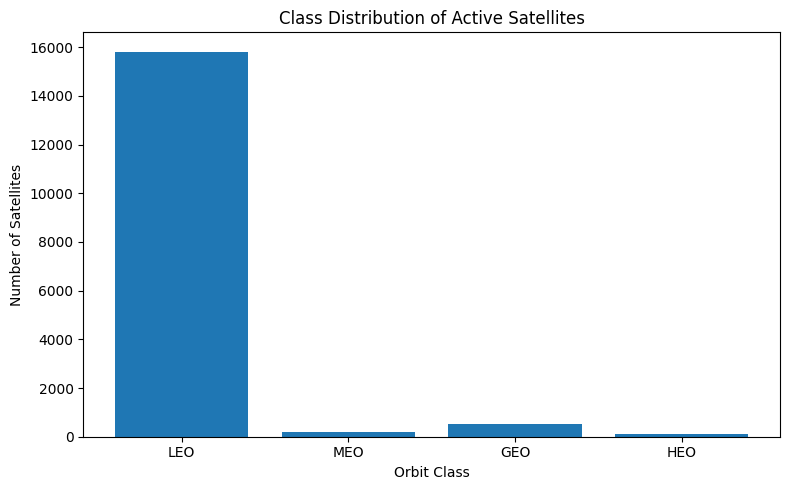

In [9]:
# ============================================================
# CELL 9 — CLASS BALANCE
# ============================================================

ORDER = [
    "LEO",
    "MEO",
    "GEO",
    "HEO"
]

class_counts = (
    df["ORBIT_CLASS"]
    .value_counts()
    .reindex(
        ORDER,
        fill_value=0
    )
)

class_percentages = (
    class_counts
    / len(df)
    * 100
)


class_balance = pd.DataFrame({
    "Class": ORDER,
    "Count": class_counts.values,
    "Percentage": class_percentages.round(2).values
})


display(class_balance)


# Plot

plt.figure(figsize=(8, 5))

plt.bar(
    class_balance["Class"],
    class_balance["Count"]
)

plt.title(
    "Class Distribution of Active Satellites"
)

plt.xlabel("Orbit Class")
plt.ylabel("Number of Satellites")

plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# CELL 10 — DEFINE ML FEATURES + LEAKAGE CONTROL
# ============================================================
#
# OPTION A — STRICT LEAKAGE CONTROL
#
# The orbit-class target is constructed using:
#
#     MEAN_MOTION
#     ECCENTRICITY
#     INCLINATION
#
# Therefore all three are excluded from the ML predictors.
#
# We also exclude quantities directly derived from them:
#
#     SEMI_MAJOR_AXIS
#     PERIGEE_RADIUS
#     APOGEE_RADIUS
#     PERIGEE_ALT_KM
#     APOGEE_ALT_KM
#     ORBITAL_PERIOD_MIN
#     ORBITAL_PERIOD_HOURS
#
# The ML model therefore learns from the remaining GP
# parameters only.
# ============================================================


# ============================================================
# 1. VARIABLES DIRECTLY USED TO CREATE THE TARGET
# ============================================================

TARGET_DEFINING_COLUMNS = [
    "MEAN_MOTION",
    "ECCENTRICITY",
    "INCLINATION",
]


# ============================================================
# 2. QUANTITIES DIRECTLY DERIVED FROM TARGET-DEFINING DATA
# ============================================================

DERIVED_LEAKAGE_COLUMNS = [
    "SEMI_MAJOR_AXIS_KM",
    "PERIGEE_RADIUS_KM",
    "APOGEE_RADIUS_KM",
    "PERIGEE_ALT_KM",
    "APOGEE_ALT_KM",
    "ORBITAL_PERIOD_MIN",
    "ORBITAL_PERIOD_HOURS",
]


# ============================================================
# 3. IDENTIFIERS / METADATA — NOT ML FEATURES
# ============================================================

IDENTIFIER_COLUMNS = [
    "OBJECT_NAME",
    "OBJECT_ID",
    "NORAD_CAT_ID",
    "EPOCH",
    "ELEMENT_SET_NO",
    "REV_AT_EPOCH",
    "EPHEMERIS_TYPE",
    "CLASSIFICATION_TYPE",
]


# ============================================================
# 4. FINAL ML FEATURE SET
# ============================================================
#
# IMPORTANT:
# MEAN_MOTION, ECCENTRICITY AND INCLINATION are deliberately
# absent because they were used to construct ORBIT_CLASS.
#
# ============================================================

FEATURE_COLUMNS = [
    "RA_OF_ASC_NODE",
    "ARG_OF_PERICENTER",
    "MEAN_ANOMALY",
    "BSTAR",
    "MEAN_MOTION_DOT",
    "MEAN_MOTION_DDOT",
]


# ============================================================
# 5. TARGET
# ============================================================

TARGET_COLUMN = "ORBIT_CLASS"


# ============================================================
# 6. COMPLETE LEAKAGE EXCLUSION LIST
# ============================================================

LEAKAGE_COLUMNS = (
    TARGET_DEFINING_COLUMNS
    + DERIVED_LEAKAGE_COLUMNS
)


# ============================================================
# 7. DISPLAY THE FINAL EXPERIMENT DESIGN
# ============================================================

print("=" * 70)
print("TARGET AND FEATURE DESIGN")
print("=" * 70)


print("\nTARGET:")
print(
    TARGET_COLUMN
)


print(
    "\nVARIABLES USED TO CONSTRUCT THE TARGET "
    "(EXCLUDED FROM ML):"
)

for col in TARGET_DEFINING_COLUMNS:
    print(
        "  -",
        col
    )


print(
    "\nDERIVED TARGET INFORMATION "
    "(EXCLUDED FROM ML):"
)

for col in DERIVED_LEAKAGE_COLUMNS:
    print(
        "  -",
        col
    )


print(
    "\nIDENTIFIERS / METADATA "
    "(EXCLUDED FROM ML):"
)

for col in IDENTIFIER_COLUMNS:
    print(
        "  -",
        col
    )


print(
    "\nFINAL ML FEATURES:"
)

for col in FEATURE_COLUMNS:
    print(
        "  +",
        col
    )


print(
    "\nNumber of ML features:",
    len(FEATURE_COLUMNS)
)

TARGET AND FEATURE DESIGN

TARGET:
ORBIT_CLASS

VARIABLES USED TO CONSTRUCT THE TARGET (EXCLUDED FROM ML):
  - MEAN_MOTION
  - ECCENTRICITY
  - INCLINATION

DERIVED TARGET INFORMATION (EXCLUDED FROM ML):
  - SEMI_MAJOR_AXIS_KM
  - PERIGEE_RADIUS_KM
  - APOGEE_RADIUS_KM
  - PERIGEE_ALT_KM
  - APOGEE_ALT_KM
  - ORBITAL_PERIOD_MIN
  - ORBITAL_PERIOD_HOURS

IDENTIFIERS / METADATA (EXCLUDED FROM ML):
  - OBJECT_NAME
  - OBJECT_ID
  - NORAD_CAT_ID
  - EPOCH
  - ELEMENT_SET_NO
  - REV_AT_EPOCH
  - EPHEMERIS_TYPE
  - CLASSIFICATION_TYPE

FINAL ML FEATURES:
  + RA_OF_ASC_NODE
  + ARG_OF_PERICENTER
  + MEAN_ANOMALY
  + BSTAR
  + MEAN_MOTION_DOT
  + MEAN_MOTION_DDOT

Number of ML features: 6


In [11]:
# ============================================================
# CELL 11 — CREATE X AND y
# ============================================================

X = df[
    FEATURE_COLUMNS
].copy()

y = df[
    TARGET_COLUMN
].copy()


print("X shape:")
print(X.shape)

print("\ny shape:")
print(y.shape)


print("\nFinal target distribution:")
display(
    y.value_counts()
    .reindex(ORDER, fill_value=0)
    .to_frame("Count")
)

X shape:
(16633, 6)

y shape:
(16633,)

Final target distribution:


,Count
ORBIT_CLASS,
LEO,15819
MEO,187
GEO,532
HEO,95


In [12]:
# ============================================================
# CELL 12 — TRAIN / VALIDATION / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split


# ------------------------------------------------------------
# First:
# 85% temporary training pool
# 15% final test
# ------------------------------------------------------------

X_train_val, X_test, y_train_val, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.15,
        random_state=RANDOM_STATE,
        stratify=y
    )
)


# ------------------------------------------------------------
# Then:
# take 15/85 of the 85% pool = 15% overall
# ------------------------------------------------------------

validation_fraction = 0.15 / 0.85


X_train, X_val, y_train, y_val = (
    train_test_split(
        X_train_val,
        y_train_val,
        test_size=validation_fraction,
        random_state=RANDOM_STATE,
        stratify=y_train_val
    )
)


print("Dataset split:")
print(
    f"Training:   {len(X_train):,} "
    f"({len(X_train)/len(X):.1%})"
)

print(
    f"Validation: {len(X_val):,} "
    f"({len(X_val)/len(X):.1%})"
)

print(
    f"Test:       {len(X_test):,} "
    f"({len(X_test)/len(X):.1%})"
)


print("\nTraining classes:")
print(y_train.value_counts())

print("\nValidation classes:")
print(y_val.value_counts())

print("\nTest classes:")
print(y_test.value_counts())

Dataset split:
Training:   11,643 (70.0%)
Validation: 2,495 (15.0%)
Test:       2,495 (15.0%)

Training classes:
ORBIT_CLASS
LEO    11073
GEO      372
MEO      131
HEO       67
Name: count, dtype: int64

Validation classes:
ORBIT_CLASS
LEO    2373
GEO      80
MEO      28
HEO      14
Name: count, dtype: int64

Test classes:
ORBIT_CLASS
LEO    2373
GEO      80
MEO      28
HEO      14
Name: count, dtype: int64


In [13]:
# ============================================================
# CELL 13 — COMMON PREPROCESSING
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler


def make_preprocessor():

    return Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),

        (
            "scaler",
            StandardScaler()
        )
    ])


print(
    "Common preprocessing:"
)

print("1. Median imputation")
print("2. StandardScaler")

Common preprocessing:
1. Median imputation
2. StandardScaler


In [14]:
# ============================================================
# CELL 14 — DEFINE ALL CLASSIFICATION MODELS
# ============================================================
#
# We now compare SEVEN models:
#
# 1. Dummy Baseline
# 2. Logistic Regression
# 3. Random Forest
# 4. HistGradientBoosting
# 5. Extra Trees
# 6. RBF Support Vector Classifier
# 7. K-Nearest Neighbors
#
# IMPORTANT:
# Every model receives exactly the same:
#
#     X_train
#     y_train
#     preprocessing pipeline
#     random seed where applicable
#
# The target-defining variables remain excluded from X:
#
#     MEAN_MOTION
#     ECCENTRICITY
#     INCLINATION
#
# ============================================================


from sklearn.dummy import DummyClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier,
    ExtraTreesClassifier,
)

from sklearn.svm import SVC

from sklearn.neighbors import KNeighborsClassifier


# ============================================================
# MODEL FACTORY
# ============================================================

def make_models():

    models = {

        # ====================================================
        # 1. SIMPLE BASELINE
        # ====================================================

        "Dummy Baseline": Pipeline([
            (
                "preprocessing",
                make_preprocessor()
            ),

            (
                "model",
                DummyClassifier(
                    strategy="most_frequent",
                    random_state=RANDOM_STATE
                )
            )
        ]),


        # ====================================================
        # 2. LOGISTIC REGRESSION
        # ====================================================
        #
        # Linear classification boundary.
        # ====================================================

        "Logistic Regression": Pipeline([
            (
                "preprocessing",
                make_preprocessor()
            ),

            (
                "model",
                LogisticRegression(
                    max_iter=3000,
                    solver="lbfgs",
                    random_state=RANDOM_STATE
                )
            )
        ]),


        # ====================================================
        # 3. RANDOM FOREST
        # ====================================================
        #
        # Nonlinear bagged decision-tree ensemble.
        # ====================================================

        "Random Forest": Pipeline([
            (
                "preprocessing",
                make_preprocessor()
            ),

            (
                "model",
                RandomForestClassifier(
                    n_estimators=400,
                    max_depth=None,
                    min_samples_split=2,
                    min_samples_leaf=1,
                    max_features="sqrt",
                    random_state=RANDOM_STATE,
                    n_jobs=1
                )
            )
        ]),


        # ====================================================
        # 4. HISTOGRAM GRADIENT BOOSTING
        # ====================================================
        #
        # Nonlinear sequential boosting model.
        # ====================================================

        "HistGradientBoosting": Pipeline([
            (
                "preprocessing",
                make_preprocessor()
            ),

            (
                "model",
                HistGradientBoostingClassifier(
                    learning_rate=0.05,
                    max_iter=400,
                    max_leaf_nodes=31,
                    l2_regularization=0.0,
                    random_state=RANDOM_STATE
                )
            )
        ]),


        # ====================================================
        # 5. EXTRA TREES
        # ====================================================
        #
        # Extra Trees differs from Random Forest by introducing
        # additional randomness into the split thresholds.
        #
        # This tests whether more randomized tree boundaries
        # work better for the orbital-feature distributions.
        # ====================================================

        "Extra Trees": Pipeline([
            (
                "preprocessing",
                make_preprocessor()
            ),

            (
                "model",
                ExtraTreesClassifier(
                    n_estimators=500,
                    max_depth=None,
                    min_samples_split=2,
                    min_samples_leaf=1,
                    max_features="sqrt",
                    random_state=RANDOM_STATE,
                    n_jobs=1
                )
            )
        ]),


        # ====================================================
        # 6. RBF SUPPORT VECTOR CLASSIFIER
        # ====================================================
        #
        # The preprocessing is particularly important here:
        #
        #     median imputation
        #            ↓
        #       StandardScaler
        #            ↓
        #          RBF SVC
        #
        # C and gamma control the nonlinear decision boundary.
        #
        # class_weight="balanced" is used because your primary
        # metric is Macro-F1 and the orbit classes may be
        # imbalanced.
        # ====================================================

        "RBF SVM": Pipeline([
            (
                "preprocessing",
                make_preprocessor()
            ),

            (
                "model",
                SVC(
                    kernel="rbf",
                    C=10.0,
                    gamma="scale",
                    class_weight="balanced",
                    probability=False,
                    random_state=RANDOM_STATE
                )
            )
        ]),


        # ====================================================
        # 7. K-NEAREST NEIGHBORS
        # ====================================================
        #
        # KNN asks:
        #
        # "Do nearby satellites in the six-dimensional feature
        # space tend to have the same orbit class?"
        #
        # StandardScaler is essential because KNN uses distance.
        #
        # distance='minkowski', p=2 = Euclidean distance.
        # weights='distance' gives closer neighbors more influence.
        # ====================================================

        "K-Nearest Neighbors": Pipeline([
            (
                "preprocessing",
                make_preprocessor()
            ),

            (
                "model",
                KNeighborsClassifier(
                    n_neighbors=15,
                    weights="distance",
                    metric="minkowski",
                    p=2,
                    n_jobs=1
                )
            )
        ])
    }


    return models


# ============================================================
# CREATE MODELS
# ============================================================

models = make_models()


# ============================================================
# DISPLAY MODEL LIST
# ============================================================

print("=" * 70)
print("MODELS IN EXPERIMENT")
print("=" * 70)

for number, model_name in enumerate(
    models.keys(),
    start=1
):

    print(
        f"{number}. {model_name}"
    )


print(
    "\nTotal models:",
    len(models)
)

MODELS IN EXPERIMENT
1. Dummy Baseline
2. Logistic Regression
3. Random Forest
4. HistGradientBoosting
5. Extra Trees
6. RBF SVM
7. K-Nearest Neighbors

Total models: 7


In [15]:
# ============================================================
# CELL 15 — TRAIN AND EVALUATE ALL MODELS
# ============================================================

import time
import joblib

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report
)


# ============================================================
# RESULTS CONTAINER
# ============================================================

results = []


# ============================================================
# TRAIN ALL MODELS
# ============================================================

for model_name, model in models.items():

    print("\n")
    print("=" * 70)
    print(
        f"TRAINING: {model_name}"
    )
    print("=" * 70)


    # --------------------------------------------------------
    # Start timer
    # --------------------------------------------------------

    start_time = time.perf_counter()


    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    model.fit(
        X_train,
        y_train
    )


    # --------------------------------------------------------
    # Training time
    # --------------------------------------------------------

    training_time = (
        time.perf_counter()
        - start_time
    )


    # --------------------------------------------------------
    # Validation predictions
    # --------------------------------------------------------

    validation_predictions = (
        model.predict(X_val)
    )


    # --------------------------------------------------------
    # Test predictions
    # --------------------------------------------------------

    test_predictions = (
        model.predict(X_test)
    )


    # ========================================================
    # VALIDATION MACRO-F1
    # ========================================================

    validation_macro_f1 = f1_score(
        y_val,
        validation_predictions,
        average="macro",
        zero_division=0
    )


    # ========================================================
    # TEST METRICS
    # ========================================================

    test_macro_f1 = f1_score(
        y_test,
        test_predictions,
        average="macro",
        zero_division=0
    )


    test_accuracy = accuracy_score(
        y_test,
        test_predictions
    )


    test_balanced_accuracy = (
        balanced_accuracy_score(
            y_test,
            test_predictions
        )
    )


    test_macro_precision = (
        precision_score(
            y_test,
            test_predictions,
            average="macro",
            zero_division=0
        )
    )


    test_macro_recall = (
        recall_score(
            y_test,
            test_predictions,
            average="macro",
            zero_division=0
        )
    )


    # ========================================================
    # SAVE MODEL
    # ========================================================

    safe_name = (
        model_name
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
    )


    model_path = (
        MODEL_DIR
        / f"{safe_name}.joblib"
    )


    joblib.dump(
        model,
        model_path,
        compress=3
    )


    model_size_kb = (
        model_path.stat().st_size
        / 1024
    )


    # ========================================================
    # STORE RESULTS
    # ========================================================

    results.append({

        "Model":
            model_name,

        "Validation Macro-F1":
            validation_macro_f1,

        "Test Macro-F1":
            test_macro_f1,

        "Test Accuracy":
            test_accuracy,

        "Test Balanced Accuracy":
            test_balanced_accuracy,

        "Test Macro Precision":
            test_macro_precision,

        "Test Macro Recall":
            test_macro_recall,

        "Training Time (seconds)":
            training_time,

        "Model Size (KB)":
            model_size_kb,

        "_model":
            model,

        "_validation_predictions":
            validation_predictions,

        "_predictions":
            test_predictions
    })


    # ========================================================
    # DISPLAY CURRENT RESULT
    # ========================================================

    print(
        f"\nValidation Macro-F1: "
        f"{validation_macro_f1:.4f}"
    )

    print(
        f"Test Macro-F1: "
        f"{test_macro_f1:.4f}"
    )

    print(
        f"Test Accuracy: "
        f"{test_accuracy:.4f}"
    )

    print(
        f"Training time: "
        f"{training_time:.3f} seconds"
    )

    print(
        f"Model size: "
        f"{model_size_kb:.2f} KB"
    )


# ============================================================
# FINISHED
# ============================================================

print("\n")
print("=" * 70)
print("ALL MODELS FINISHED")
print("=" * 70)

print(
    "\nModels trained:",
    len(results)
)



TRAINING: Dummy Baseline

Validation Macro-F1: 0.2437
Test Macro-F1: 0.2437
Test Accuracy: 0.9511
Training time: 0.030 seconds
Model size: 1.18 KB


TRAINING: Logistic Regression

Validation Macro-F1: 0.2437
Test Macro-F1: 0.2438
Test Accuracy: 0.9511
Training time: 0.101 seconds
Model size: 1.53 KB


TRAINING: Random Forest

Validation Macro-F1: 0.8114
Test Macro-F1: 0.8031
Test Accuracy: 0.9924
Training time: 8.896 seconds
Model size: 2128.67 KB


TRAINING: HistGradientBoosting

Validation Macro-F1: 0.8306
Test Macro-F1: 0.8453
Test Accuracy: 0.9928
Training time: 1.164 seconds
Model size: 445.98 KB


TRAINING: Extra Trees

Validation Macro-F1: 0.6530
Test Macro-F1: 0.6315
Test Accuracy: 0.9776
Training time: 4.005 seconds
Model size: 21068.34 KB


TRAINING: RBF SVM

Validation Macro-F1: 0.4475
Test Macro-F1: 0.4182
Test Accuracy: 0.7667
Training time: 11.922 seconds
Model size: 284.82 KB


TRAINING: K-Nearest Neighbors

Validation Macro-F1: 0.5717
Test Macro-F1: 0.5459
Test Accura

In [16]:
# ============================================================
# CELL 16 — MODEL COMPARISON
# ============================================================

import pandas as pd


# ============================================================
# CREATE RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(
    results
)


results_table = results_df[
    [
        "Model",
        "Validation Macro-F1",
        "Test Macro-F1",
        "Test Accuracy",
        "Test Balanced Accuracy",
        "Test Macro Precision",
        "Test Macro Recall",
        "Training Time (seconds)",
        "Model Size (KB)"
    ]
].copy()


# ============================================================
# RANK USING VALIDATION MACRO-F1
# ============================================================
#
# IMPORTANT:
# The final test set is NOT used to choose the best model.
# ============================================================

results_table = (
    results_table
    .sort_values(
        "Validation Macro-F1",
        ascending=False
    )
    .reset_index(drop=True)
)


# ============================================================
# ADD RANK
# ============================================================

results_table.insert(
    0,
    "Validation Rank",
    range(
        1,
        len(results_table) + 1
    )
)


# ============================================================
# DISPLAY
# ============================================================

print("=" * 70)
print("MODEL COMPARISON — VALIDATION MACRO-F1 RANKING")
print("=" * 70)


display(
    results_table.style.format({

        "Validation Macro-F1":
            "{:.4f}",

        "Test Macro-F1":
            "{:.4f}",

        "Test Accuracy":
            "{:.4f}",

        "Test Balanced Accuracy":
            "{:.4f}",

        "Test Macro Precision":
            "{:.4f}",

        "Test Macro Recall":
            "{:.4f}",

        "Training Time (seconds)":
            "{:.3f}",

        "Model Size (KB)":
            "{:.2f}"
    })
)


# ============================================================
# BEST MODEL
# ============================================================

best_model_name = (
    results_table.iloc[0]["Model"]
)

best_validation_f1 = (
    results_table.iloc[0][
        "Validation Macro-F1"
    ]
)


print(
    "\nBest model:"
)

print(
    best_model_name
)


print(
    "\nBest validation Macro-F1:"
)

print(
    f"{best_validation_f1:.4f}"
)

# ============================================================
# SAVE RESULTS
# ============================================================

results_table.to_csv(
    RESULTS_CSV,
    index=False
)


print(
    "\nResults saved to:"
)

print(
    RESULTS_CSV
)

MODEL COMPARISON — VALIDATION MACRO-F1 RANKING


,Validation Rank,Model,Validation Macro-F1,Test Macro-F1,Test Accuracy,Test Balanced Accuracy,Test Macro Precision,Test Macro Recall,Training Time (seconds),Model Size (KB)
0,1,HistGradientBoosting,0.8306,0.8453,0.9928,0.8324,0.8622,0.8324,1.164,445.98
1,2,Random Forest,0.8114,0.8031,0.9924,0.7704,0.8747,0.7704,8.896,2128.67
2,3,Extra Trees,0.6530,0.6315,0.9776,0.5859,0.7461,0.5859,4.005,21068.34
3,4,K-Nearest Neighbors,0.5717,0.5459,0.9719,0.4892,0.7562,0.4892,0.032,950.50
4,5,RBF SVM,0.4475,0.4182,0.7667,0.6745,0.3920,0.6745,11.922,284.82
5,6,Logistic Regression,0.2437,0.2438,0.9511,0.2500,0.2379,0.2500,0.101,1.53
6,7,Dummy Baseline,0.2437,0.2437,0.9511,0.2500,0.2378,0.2500,0.030,1.18



Best model:
HistGradientBoosting

Best validation Macro-F1:
0.8306

Results saved to:
/content/drive/MyDrive/CelesTrak_Active_Satellites/runs/2026-10-04/run_20261004_211451_853876/results/model_comparison.csv


In [17]:
# ============================================================
# CELL 17 — DETAILED CLASSIFICATION REPORTS
# ============================================================

for result in results:

    print("\n")
    print("=" * 70)
    print(result["Model"])
    print("=" * 70)

    print(
        classification_report(
            y_test,
            result["_predictions"],
            labels=ORDER,
            zero_division=0
        )
    )



Dummy Baseline
              precision    recall  f1-score   support

         LEO       0.95      1.00      0.97      2373
         MEO       0.00      0.00      0.00        28
         GEO       0.00      0.00      0.00        80
         HEO       0.00      0.00      0.00        14

    accuracy                           0.95      2495
   macro avg       0.24      0.25      0.24      2495
weighted avg       0.90      0.95      0.93      2495



Logistic Regression
              precision    recall  f1-score   support

         LEO       0.95      1.00      0.98      2373
         MEO       0.00      0.00      0.00        28
         GEO       0.00      0.00      0.00        80
         HEO       0.00      0.00      0.00        14

    accuracy                           0.95      2495
   macro avg       0.24      0.25      0.24      2495
weighted avg       0.90      0.95      0.93      2495



Random Forest
              precision    recall  f1-score   support

         LEO       1

Best model selected using validation Macro-F1:
HistGradientBoosting


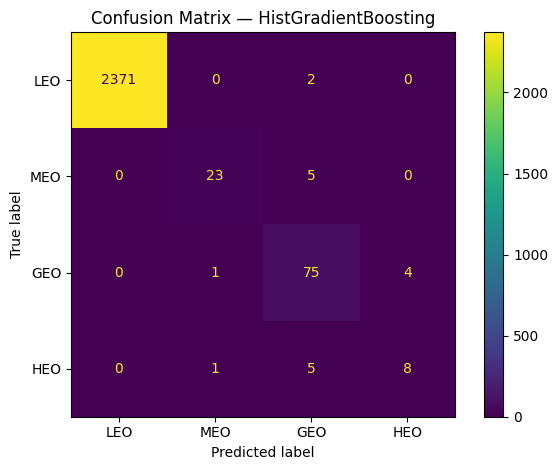

In [18]:
# ============================================================
# CELL 18 — BEST MODEL CONFUSION MATRIX
# ============================================================

from sklearn.metrics import ConfusionMatrixDisplay


best_model_name = results_table.iloc[0]["Model"]

best_result = next(
    result
    for result in results
    if result["Model"] == best_model_name
)


best_predictions = (
    best_result["_predictions"]
)


print(
    "Best model selected using validation Macro-F1:"
)

print(
    best_model_name
)


ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_predictions,
    labels=ORDER,
    display_labels=ORDER,
    values_format="d"
)

plt.title(
    f"Confusion Matrix — {best_model_name}"
)

plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# CELL 19 — DATA PROPERTY ANALYSIS
# ============================================================
#
# Assignment requirement:
#
# "Explain why the best method won. Point to a property of
#  the data, not a property of the algorithm."
#
# We therefore examine two things separately:
#
# A. Variables used to DEFINE the orbit-class target
#    (not ML predictors)
#
# B. Variables actually available to the ML models
#
# This prevents confusion between target construction and
# predictive features.
# ============================================================


print("=" * 70)
print("DATA PROPERTY ANALYSIS")
print("=" * 70)


# ============================================================
# A. TARGET-DEFINING VARIABLES
# ============================================================

TARGET_ANALYSIS_FEATURES = [
    "MEAN_MOTION",
    "ECCENTRICITY",
    "INCLINATION",
    "PERIGEE_ALT_KM",
    "APOGEE_ALT_KM",
    "ORBITAL_PERIOD_HOURS",
]


target_definition_summary = (
    df.groupby("ORBIT_CLASS")[
        TARGET_ANALYSIS_FEATURES
    ]
    .median()
    .reindex(ORDER)
)


print(
    "\nA. TARGET-DEFINING / DERIVED ORBITAL VARIABLES"
)

print(
    "\nThese variables explain how the labels were "
    "constructed and are NOT ML predictors.\n"
)

display(
    target_definition_summary
)


# ============================================================
# B. ACTUAL ML PREDICTORS
# ============================================================

ML_ANALYSIS_FEATURES = FEATURE_COLUMNS.copy()


ml_feature_summary = (
    df.groupby("ORBIT_CLASS")[
        ML_ANALYSIS_FEATURES
    ]
    .median()
    .reindex(ORDER)
)


print(
    "\nB. ACTUAL ML PREDICTORS"
)

print(
    "\nThese are the six variables actually supplied "
    "to the machine-learning models.\n"
)

display(
    ml_feature_summary
)

DATA PROPERTY ANALYSIS

A. TARGET-DEFINING / DERIVED ORBITAL VARIABLES

These variables explain how the labels were constructed and are NOT ML predictors.



,MEAN_MOTION,ECCENTRICITY,INCLINATION,PERIGEE_ALT_KM,APOGEE_ALT_KM,ORBITAL_PERIOD_HOURS
ORBIT_CLASS,,,,,,
LEO,15.295821,0.000148,53.1602,474.722714,479.516528,1.569056
MEO,2.005658,0.000723,55.0493,19867.042310,20357.897187,11.966146
GEO,1.002712,0.000243,0.0539,35776.480911,35796.914855,23.935090
HEO,1.002735,0.009558,28.9997,35331.570455,36188.983862,23.934548



B. ACTUAL ML PREDICTORS

These are the six variables actually supplied to the machine-learning models.



,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT
ORBIT_CLASS,,,,,,
LEO,201.1504,101.0549,258.44150,0.000153,2.055000e-05,0.0
MEO,210.8464,208.2030,166.06930,0.000000,-7.000000e-08,0.0
GEO,93.2011,147.2959,185.05865,0.000000,-1.265000e-06,0.0
HEO,83.0442,208.5308,113.85480,0.000000,-1.300000e-06,0.0


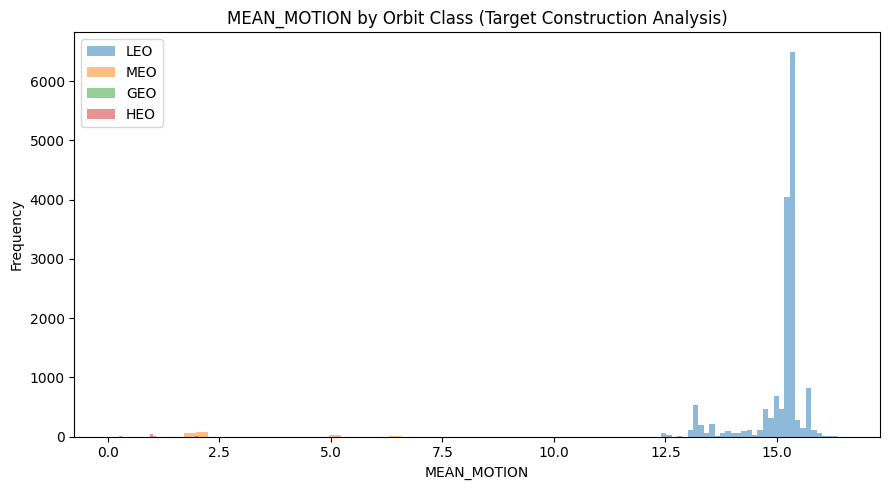

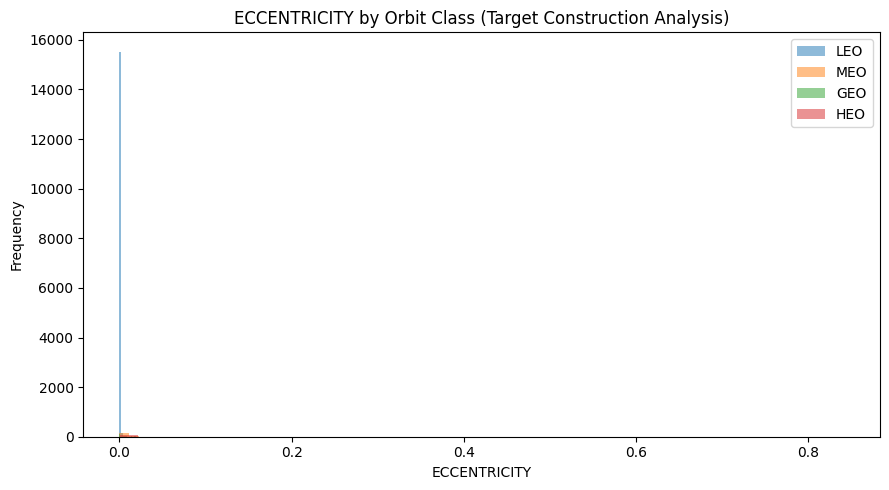

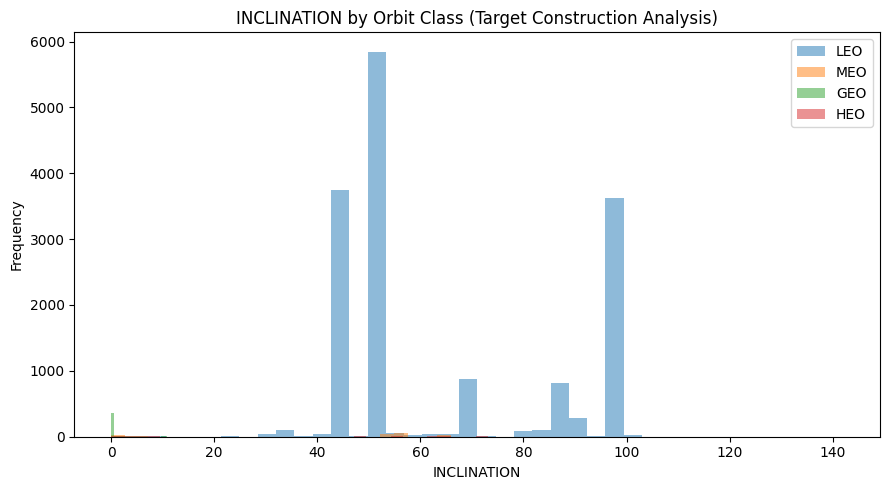

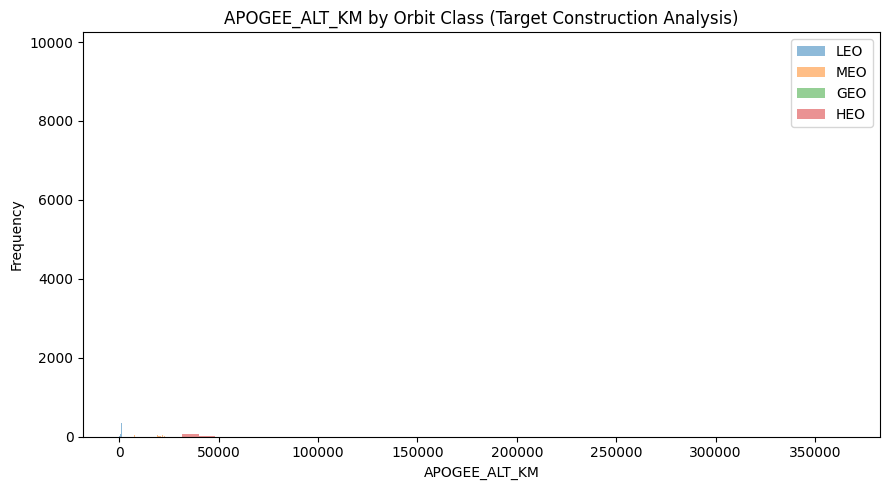

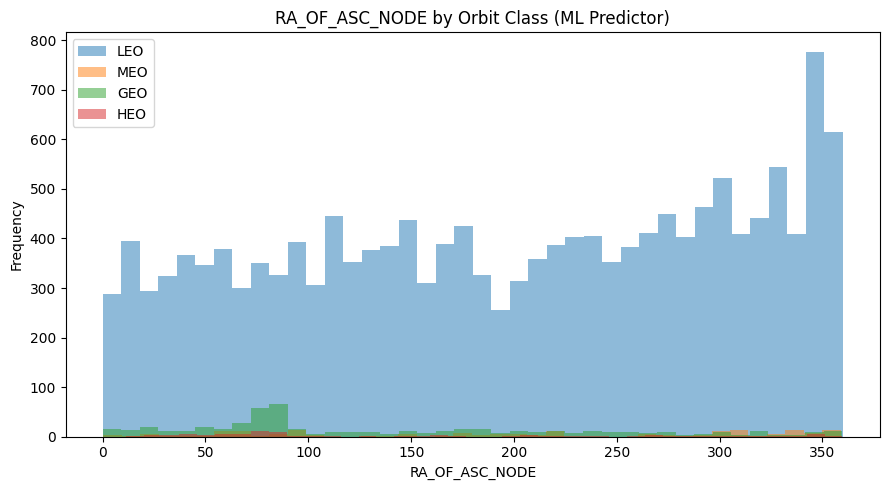

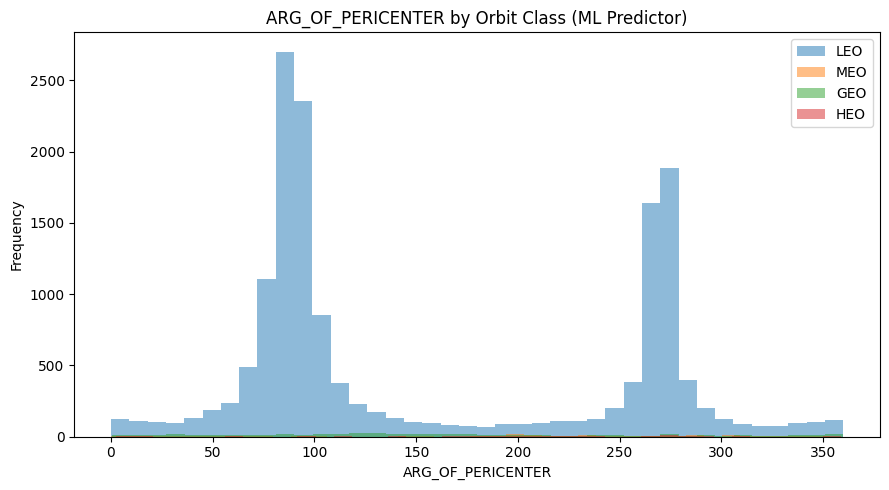

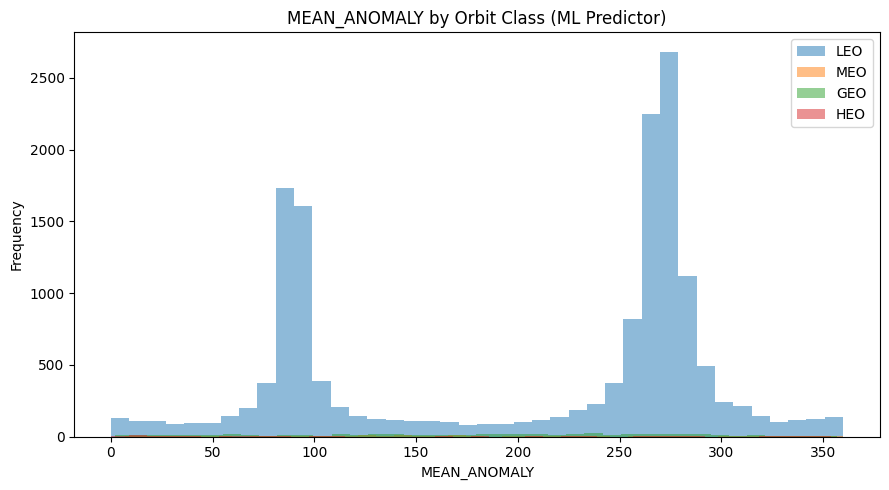

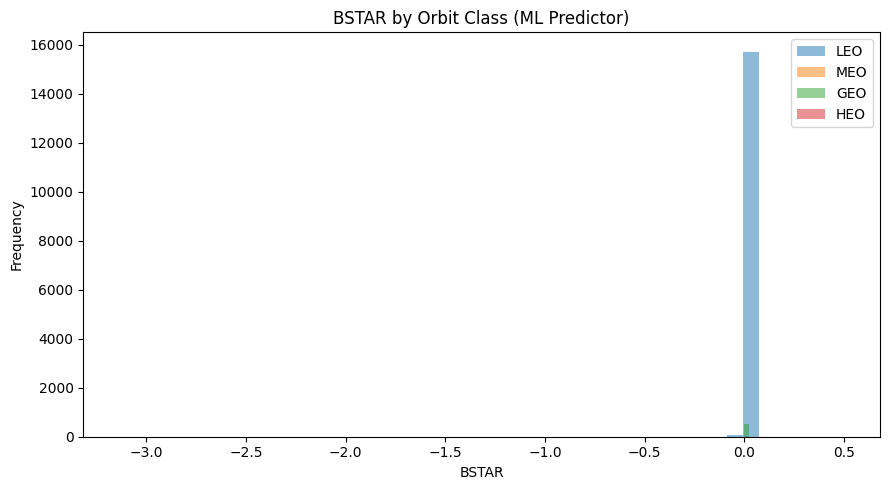

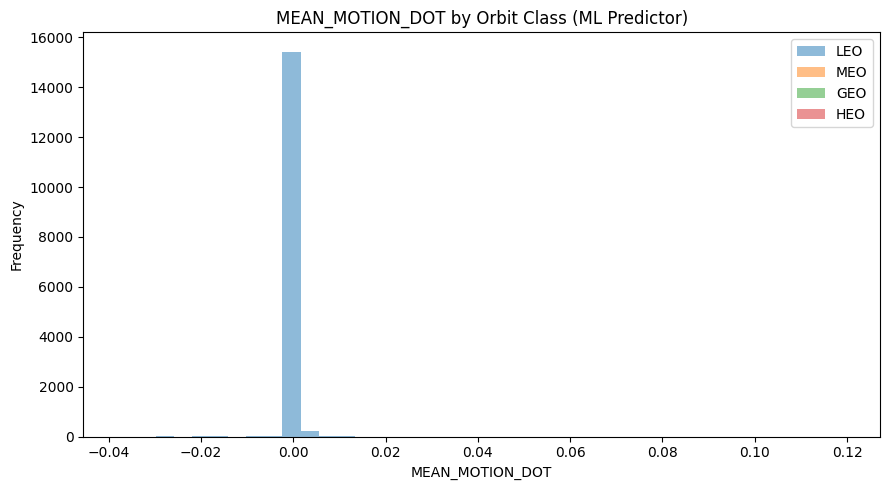

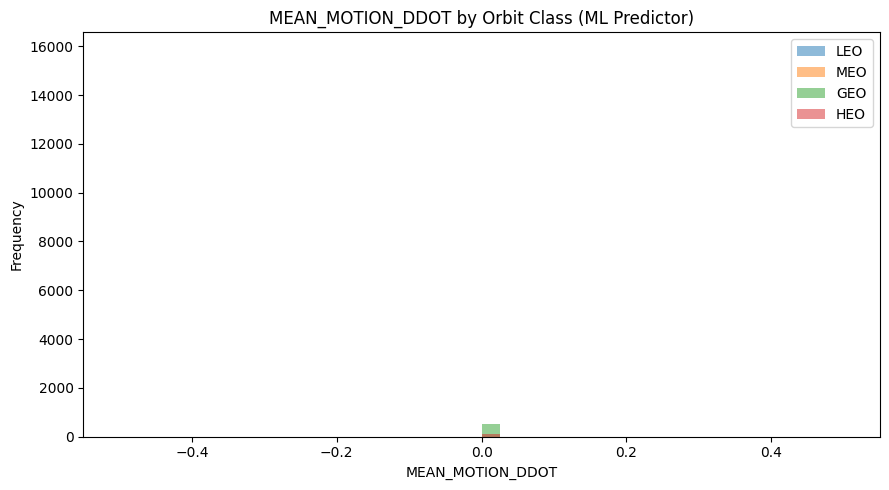

In [20]:
# ============================================================
# CELL 20 — ORBIT-CLASS DATA DISTRIBUTION PLOTS
# ============================================================


# ============================================================
# PART A — VARIABLES USED TO DEFINE THE TARGET
# ============================================================
#
# These plots are NOT ML-feature plots.
# They are included to demonstrate the physical separation
# underlying the label definitions.
# ============================================================

target_definition_plots = [
    "MEAN_MOTION",
    "ECCENTRICITY",
    "INCLINATION",
    "APOGEE_ALT_KM",
]


for feature in target_definition_plots:

    plt.figure(
        figsize=(9, 5)
    )


    for orbit_class in ORDER:

        values = (
            df.loc[
                df["ORBIT_CLASS"] == orbit_class,
                feature
            ]
            .dropna()
        )


        if len(values) == 0:
            continue


        plt.hist(
            values,
            bins=40,
            alpha=0.5,
            label=orbit_class
        )


    plt.title(
        f"{feature} by Orbit Class "
        "(Target Construction Analysis)"
    )

    plt.xlabel(
        feature
    )

    plt.ylabel(
        "Frequency"
    )

    plt.legend()

    plt.tight_layout()

    plt.show()


# ============================================================
# PART B — ACTUAL ML PREDICTORS
# ============================================================

ml_feature_plots = FEATURE_COLUMNS.copy()


for feature in ml_feature_plots:

    plt.figure(
        figsize=(9, 5)
    )


    for orbit_class in ORDER:

        values = (
            df.loc[
                df["ORBIT_CLASS"] == orbit_class,
                feature
            ]
            .dropna()
        )


        if len(values) == 0:
            continue


        plt.hist(
            values,
            bins=40,
            alpha=0.5,
            label=orbit_class
        )


    plt.title(
        f"{feature} by Orbit Class "
        "(ML Predictor)"
    )

    plt.xlabel(
        feature
    )

    plt.ylabel(
        "Frequency"
    )

    plt.legend()

    plt.tight_layout()

    plt.show()

In [21]:
# ============================================================
# CELL 21 — PERMUTATION IMPORTANCE
# ============================================================

from sklearn.inspection import permutation_importance


best_pipeline = best_result["_model"]


permutation = permutation_importance(
    best_pipeline,
    X_val,
    y_val,
    scoring="f1_macro",
    n_repeats=10,
    random_state=RANDOM_STATE
)


importance_df = pd.DataFrame({
    "Feature": FEATURE_COLUMNS,
    "Mean Importance":
        permutation.importances_mean,
    "Std":
        permutation.importances_std
})


importance_df = (
    importance_df
    .sort_values(
        "Mean Importance",
        ascending=False
    )
    .reset_index(drop=True)
)


display(
    importance_df.style.format({
        "Mean Importance": "{:.5f}",
        "Std": "{:.5f}"
    })
)

,Feature,Mean Importance,Std
0,BSTAR,0.53887,0.01349
1,MEAN_MOTION_DOT,0.29455,0.02712
2,ARG_OF_PERICENTER,0.16425,0.02468
3,MEAN_ANOMALY,0.10890,0.03525
4,RA_OF_ASC_NODE,0.09569,0.02105
5,MEAN_MOTION_DDOT,0.00000,0.00000


In [22]:
# ============================================================
# CELL 22 — ABLATION STUDY
# ============================================================

ABLATION_FEATURES = [
    feature
    for feature in FEATURE_COLUMNS
    if feature != "BSTAR"
]


print("Full feature set:")
print(FEATURE_COLUMNS)

print("\nAblated feature set:")
print(ABLATION_FEATURES)


X_ablation = df[
    ABLATION_FEATURES
].copy()

y_ablation = y.copy()


# ------------------------------------------------------------
# SAME SPLIT
# SAME RANDOM STATE
# ------------------------------------------------------------

X_ab_train_val, X_ab_test, y_ab_train_val, y_ab_test = (
    train_test_split(
        X_ablation,
        y_ablation,
        test_size=0.15,
        random_state=RANDOM_STATE,
        stratify=y_ablation
    )
)


X_ab_train, X_ab_val, y_ab_train, y_ab_val = (
    train_test_split(
        X_ab_train_val,
        y_ab_train_val,
        test_size=validation_fraction,
        random_state=RANDOM_STATE,
        stratify=y_ab_train_val
    )
)


# ------------------------------------------------------------
# REBUILD EXACT SAME FOUR MODELS
# ------------------------------------------------------------

ablation_models = make_models()

ablation_results = []


for model_name, model in ablation_models.items():

    print(
        "\nAblation model:",
        model_name
    )

    start_time = time.perf_counter()

    model.fit(
        X_ab_train,
        y_ab_train
    )

    elapsed = (
        time.perf_counter()
        - start_time
    )


    ab_val_predictions = model.predict(
        X_ab_val
    )

    ab_test_predictions = model.predict(
        X_ab_test
    )


    ab_val_f1 = f1_score(
        y_ab_val,
        ab_val_predictions,
        average="macro",
        zero_division=0
    )

    ab_test_f1 = f1_score(
        y_ab_test,
        ab_test_predictions,
        average="macro",
        zero_division=0
    )

    ab_test_accuracy = accuracy_score(
        y_ab_test,
        ab_test_predictions
    )


    ablation_results.append({
        "Model": model_name,
        "Validation Macro-F1": ab_val_f1,
        "Test Macro-F1": ab_test_f1,
        "Test Accuracy": ab_test_accuracy,
        "Training Time (seconds)": elapsed
    })


ablation_table = pd.DataFrame(
    ablation_results
).sort_values(
    "Validation Macro-F1",
    ascending=False
).reset_index(drop=True)


display(
    ablation_table.style.format({
        "Validation Macro-F1": "{:.4f}",
        "Test Macro-F1": "{:.4f}",
        "Test Accuracy": "{:.4f}",
        "Training Time (seconds)": "{:.4f}"
    })
)


ablation_table.to_csv(
    ABLATION_CSV,
    index=False
)

Full feature set:
['RA_OF_ASC_NODE', 'ARG_OF_PERICENTER', 'MEAN_ANOMALY', 'BSTAR', 'MEAN_MOTION_DOT', 'MEAN_MOTION_DDOT']

Ablated feature set:
['RA_OF_ASC_NODE', 'ARG_OF_PERICENTER', 'MEAN_ANOMALY', 'MEAN_MOTION_DOT', 'MEAN_MOTION_DDOT']

Ablation model: Dummy Baseline

Ablation model: Logistic Regression

Ablation model: Random Forest

Ablation model: HistGradientBoosting

Ablation model: Extra Trees

Ablation model: RBF SVM

Ablation model: K-Nearest Neighbors


,Model,Validation Macro-F1,Test Macro-F1,Test Accuracy,Training Time (seconds)
0,HistGradientBoosting,0.7480,0.7384,0.9848,0.8236
1,Random Forest,0.6791,0.6117,0.9808,10.4526
2,Extra Trees,0.6092,0.5836,0.9739,3.8798
3,K-Nearest Neighbors,0.5717,0.5459,0.9719,0.0296
4,RBF SVM,0.4427,0.4181,0.7711,10.7352
5,Logistic Regression,0.2437,0.2438,0.9511,0.0941
6,Dummy Baseline,0.2437,0.2437,0.9511,0.0164


In [23]:
# ============================================================
# CELL 23 — COMPARE FULL VS ABLATION RANKING
# ============================================================

full_ranking = results_table[
    [
        "Model",
        "Validation Macro-F1"
    ]
].copy()

full_ranking["Experiment"] = "Full features"

full_ranking["Rank"] = (
    full_ranking[
        "Validation Macro-F1"
    ]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)


ablation_ranking = ablation_table[
    [
        "Model",
        "Validation Macro-F1"
    ]
].copy()

ablation_ranking["Experiment"] = (
    "Without BSTAR"
)

ablation_ranking["Rank"] = (
    ablation_ranking[
        "Validation Macro-F1"
    ]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)


ranking_comparison = pd.concat(
    [
        full_ranking,
        ablation_ranking
    ],
    ignore_index=True
)


display(
    ranking_comparison
)

,Model,Validation Macro-F1,Experiment,Rank
0,HistGradientBoosting,0.830564,Full features,1
1,Random Forest,0.811381,Full features,2
2,Extra Trees,0.652982,Full features,3
3,K-Nearest Neighbors,0.571731,Full features,4
4,RBF SVM,0.447532,Full features,5
5,Logistic Regression,0.243735,Full features,6
6,Dummy Baseline,0.243735,Full features,6
7,HistGradientBoosting,0.748008,Without BSTAR,1
8,Random Forest,0.679109,Without BSTAR,2
9,Extra Trees,0.609229,Without BSTAR,3


In [24]:
# ============================================================
# CELL 24 — SAVE PROCESSED DATASET FOR THIS RUN
# ============================================================
#
# The processed dataset contains:
#
#   1. Original CelesTrak GP parameters
#   2. Derived orbital quantities
#   3. Detailed ESA-style orbital regime
#   4. Final four-class assignment target
#
# The detailed ESA_ORBIT_REGIME is retained for transparency,
# while ORBIT_CLASS is the actual four-class ML target:
#
#     LEO
#     MEO
#     GEO
#     HEO
#
# ============================================================


# ============================================================
# COLUMNS TO SAVE
# ============================================================

SAVE_COLUMNS = [

    # --------------------------------------------------------
    # Satellite identification
    # --------------------------------------------------------

    "OBJECT_NAME",
    "OBJECT_ID",
    "EPOCH",
    "NORAD_CAT_ID",


    # --------------------------------------------------------
    # Original CelesTrak GP orbital parameters
    # --------------------------------------------------------

    "MEAN_MOTION",
    "ECCENTRICITY",
    "INCLINATION",
    "RA_OF_ASC_NODE",
    "ARG_OF_PERICENTER",
    "MEAN_ANOMALY",

    "BSTAR",
    "MEAN_MOTION_DOT",
    "MEAN_MOTION_DDOT",


    # --------------------------------------------------------
    # Derived orbital quantities
    #
    # These were used for orbit-regime construction but are
    # excluded from the ML predictor set.
    # --------------------------------------------------------

    "MEAN_MOTION_RAD_S",

    "SEMI_MAJOR_AXIS_KM",

    "PERIGEE_RADIUS_KM",

    "APOGEE_RADIUS_KM",

    "PERIGEE_ALT_KM",

    "APOGEE_ALT_KM",

    "ORBITAL_PERIOD_MIN",

    "ORBITAL_PERIOD_HOURS",


    # --------------------------------------------------------
    # Detailed ESA-style orbital regime
    # --------------------------------------------------------
    #
    # Examples:
    #
    #   LEO
    #   LMO
    #   MEO
    #   NSO
    #   GEO
    #   GTO
    #   MGO
    #   IGO
    #   EGO
    #   GHO
    #   HEO
    #   HAO
    # --------------------------------------------------------

    "ESA_ORBIT_REGIME",


    # --------------------------------------------------------
    # Final four-class ML target
    # --------------------------------------------------------

    "ORBIT_CLASS"
]


# ============================================================
# KEEP ONLY COLUMNS THAT ACTUALLY EXIST
# ============================================================

SAVE_COLUMNS = [
    col
    for col in SAVE_COLUMNS
    if col in df.columns
]


# ============================================================
# SAVE PROCESSED DATASET
# ============================================================

df[
    SAVE_COLUMNS
].to_csv(
    PROCESSED_CSV,
    index=False
)


# ============================================================
# VERIFY SAVED FILE
# ============================================================

saved_df = pd.read_csv(
    PROCESSED_CSV
)


# ============================================================
# DISPLAY SUMMARY
# ============================================================

print("=" * 70)
print("PROCESSED DATASET SAVED")
print("=" * 70)


print(
    "\nRun ID:"
)

print(
    RUN_ID
)


print(
    "\nFile:"
)

print(
    PROCESSED_CSV
)


print(
    "\nRows:"
)

print(
    f"{len(saved_df):,}"
)


print(
    "\nColumns saved:"
)

for col in saved_df.columns:

    print(
        "  -",
        col
    )


# ============================================================
# VERIFY FINAL FOUR CLASSES
# ============================================================

print(
    "\n" + "=" * 70
)

print(
    "FINAL FOUR-CLASS DISTRIBUTION"
)

print(
    "=" * 70
)


final_class_counts = (
    saved_df["ORBIT_CLASS"]
    .value_counts()
    .reindex(
        [
            "LEO",
            "MEO",
            "GEO",
            "HEO"
        ],
        fill_value=0
    )
)


display(
    final_class_counts.to_frame(
        name="Satellite Count"
    )
)


# ============================================================
# VERIFY ESA DETAILED REGIMES
# ============================================================

print(
    "\n" + "=" * 70
)

print(
    "ESA-STYLE DETAILED ORBIT REGIMES"
)

print(
    "=" * 70
)


esa_regime_counts = (
    saved_df["ESA_ORBIT_REGIME"]
    .value_counts()
)


display(
    esa_regime_counts.to_frame(
        name="Satellite Count"
    )
)


print(
    "\nProcessed dataset successfully saved."
)

print(
    "It contains both the detailed ESA-style regime "
    "and the final four-class ML target."
)

PROCESSED DATASET SAVED

Run ID:
20261004_211451_853876

File:
/content/drive/MyDrive/CelesTrak_Active_Satellites/runs/2026-10-04/run_20261004_211451_853876/active_satellites_with_orbit_class.csv

Rows:
16,633

Columns saved:
  - OBJECT_NAME
  - OBJECT_ID
  - EPOCH
  - NORAD_CAT_ID
  - MEAN_MOTION
  - ECCENTRICITY
  - INCLINATION
  - RA_OF_ASC_NODE
  - ARG_OF_PERICENTER
  - MEAN_ANOMALY
  - BSTAR
  - MEAN_MOTION_DOT
  - MEAN_MOTION_DDOT
  - MEAN_MOTION_RAD_S
  - SEMI_MAJOR_AXIS_KM
  - PERIGEE_RADIUS_KM
  - APOGEE_RADIUS_KM
  - PERIGEE_ALT_KM
  - APOGEE_ALT_KM
  - ORBITAL_PERIOD_MIN
  - ORBITAL_PERIOD_HOURS
  - ESA_ORBIT_REGIME
  - ORBIT_CLASS

FINAL FOUR-CLASS DISTRIBUTION


,Satellite Count
ORBIT_CLASS,
LEO,15819
MEO,187
GEO,532
HEO,95



ESA-STYLE DETAILED ORBIT REGIMES


,Satellite Count
ESA_ORBIT_REGIME,
LEO,15819
GEO,532
NSO,137
MEO,43
EGO,35
HEO,22
IGO,21
GTO,10
LMO,7



Processed dataset successfully saved.
It contains both the detailed ESA-style regime and the final four-class ML target.


In [25]:
# ============================================================
# CELL 25 — SAVE COMPLETE EXPERIMENT METADATA
# ============================================================
#
# This metadata file documents exactly how this run was
# constructed and makes the experiment reproducible.
#
# It records:
#
#   - Dataset source
#   - Exact daily snapshot
#   - SHA-256
#   - Dataset dimensions
#   - Run ID
#   - Random seed
#   - Train/validation/test split
#   - ML features
#   - Leakage exclusions
#   - Four orbit classes
#   - ESA detailed taxonomy
#   - ESA → four-class mapping
#   - Actual class distributions
#   - Ablation definition
#
# ============================================================


import json
import hashlib
import pandas as pd


# ============================================================
# 1. VERIFY REQUIRED VARIABLES
# ============================================================

required_metadata_variables = [

    "RUN_ID",

    "TODAY_FILE",

    "RAW_CSV",

    "PROCESSED_CSV",

    "CELESTRAK_URL",

    "GITHUB_RUN_PREFIX",

    "FEATURE_COLUMNS",

    "TARGET_DEFINING_COLUMNS",

    "DERIVED_LEAKAGE_COLUMNS",

    "IDENTIFIER_COLUMNS",

    "ORDER",

    "RANDOM_STATE",

    "METADATA_JSON"
]


missing_metadata_variables = [

    variable

    for variable in required_metadata_variables

    if variable not in globals()
]


if missing_metadata_variables:

    raise RuntimeError(
        "Cell 25 is missing required variables:\n\n"
        + "\n".join(
            f"  - {variable}"
            for variable in missing_metadata_variables
        )
        + "\n\n"
        "Run the current Cell 2 and Cell 3 first."
    )


# ============================================================
# 2. VERIFY FILES EXIST
# ============================================================

if not TODAY_FILE.exists():

    raise RuntimeError(
        "Today's CelesTrak dataset does not exist:\n\n"
        f"{TODAY_FILE}\n\n"
        "Run Cell 3 first."
    )


if not PROCESSED_CSV.exists():

    raise RuntimeError(
        "The processed dataset does not exist:\n\n"
        f"{PROCESSED_CSV}\n\n"
        "Run Cell 24 first."
    )


# ============================================================
# 3. CALCULATE SHA-256 OF RAW CELESTRAK SNAPSHOT
# ============================================================

CURRENT_DATA_SHA256 = hashlib.sha256(
    TODAY_FILE.read_bytes()
).hexdigest()


# ============================================================
# 4. LOAD DATASETS
# ============================================================

metadata_df = pd.read_csv(
    RAW_CSV
)


processed_metadata_df = pd.read_csv(
    PROCESSED_CSV
)


# ============================================================
# 5. DETERMINE LATEST EPOCH
# ============================================================

latest_epoch = None


if "EPOCH" in metadata_df.columns:

    epoch_series = pd.to_datetime(
        metadata_df["EPOCH"],
        errors="coerce",
        utc=True
    )


    if epoch_series.notna().any():

        latest_epoch = (
            epoch_series
            .max()
            .isoformat()
        )


# ============================================================
# 6. FINAL FOUR-CLASS COUNTS
# ============================================================

four_class_order = [
    "LEO",
    "MEO",
    "GEO",
    "HEO"
]


four_class_counts = (
    processed_metadata_df[
        "ORBIT_CLASS"
    ]
    .value_counts()
    .reindex(
        four_class_order,
        fill_value=0
    )
)


four_class_percentages = (
    four_class_counts
    / len(processed_metadata_df)
    * 100.0
)


four_class_distribution = {

    orbit_class: {

        "count":
            int(
                four_class_counts[
                    orbit_class
                ]
            ),

        "percentage":
            round(
                float(
                    four_class_percentages[
                        orbit_class
                    ]
                ),
                4
            )
    }

    for orbit_class in four_class_order
}


# ============================================================
# 7. ESA DETAILED REGIME COUNTS
# ============================================================

esa_regime_counts = (
    processed_metadata_df[
        "ESA_ORBIT_REGIME"
    ]
    .value_counts()
)


esa_regime_distribution = {

    str(regime): int(count)

    for regime, count
    in esa_regime_counts.items()
}


# ============================================================
# 8. ESA → FOUR-CLASS MAPPING
# ============================================================
#
# IMPORTANT:
#
# This is our coarse aggregation for the assignment.
#
# It is NOT being represented as ESA's official four-class
# taxonomy.
# ============================================================

ESA_TO_FOUR_CLASS = {

    # LEO family
    "LEO":
        "LEO",


    # MEO family
    "LMO":
        "MEO",

    "MEO":
        "MEO",

    "NSO":
        "MEO",


    # GEO
    "GEO":
        "GEO",


    # Broad HEO / high-altitude family
    "GTO":
        "HEO",

    "MGO":
        "HEO",

    "IGO":
        "HEO",

    "EGO":
        "HEO",

    "GHO":
        "HEO",

    "HEO":
        "HEO",

    "HAO":
        "HEO"
}


# ============================================================
# 9. ORBIT DEFINITIONS
# ============================================================

orbit_definitions = {

    "LEO": (
        "Broad assignment class based on the ESA LEO "
        "regime: perigee and apogee within approximately "
        "0–2000 km."
    ),

    "MEO": (
        "Broad assignment class containing ESA MEO, "
        "NSO and LMO regimes, representing orbital "
        "regimes extending through the medium-Earth "
        "altitude range."
    ),

    "GEO": (
        "ESA GEO regime: inclination <= 25 degrees and "
        "both perigee and apogee within approximately "
        "35586–35986 km."
    ),

    "HEO": (
        "Assignment-level high-Earth umbrella containing "
        "ESA GTO, MGO, IGO, EGO, GHO, HEO and HAO regimes. "
        "This is intentionally broader than ESA's specific "
        "HEO (Highly Eccentric Earth Orbit) category."
    )
}


# ============================================================
# 10. CREATE METADATA
# ============================================================

metadata = {

    # ========================================================
    # RUN IDENTIFICATION
    # ========================================================

    "run_id":
        RUN_ID,

    "run_date_uae":
        TODAY_DATE,

    "run_directory_google_drive":
        str(RUN_DIR),

    "run_directory_github":
        GITHUB_RUN_PREFIX,


    # ========================================================
    # DATASET
    # ========================================================

    "dataset":
        "CelesTrak Active Satellites GP CSV",

    "source_url":
        CELESTRAK_URL,

    "daily_snapshot_file":
        TODAY_FILE.name,

    "daily_snapshot_path_google_drive":
        str(TODAY_FILE),

    "github_dataset_path":
        GITHUB_DATASET_PATH,

    "data_sha256":
        CURRENT_DATA_SHA256,

    "rows_used":
        int(len(metadata_df)),

    "columns_in_source_file":
        int(len(metadata_df.columns)),

    "latest_epoch_in_dataset":
        latest_epoch,


    # ========================================================
    # EXPERIMENT CONFIGURATION
    # ========================================================

    "random_state":
        RANDOM_STATE,

    "train_fraction":
        0.70,

    "validation_fraction":
        0.15,

    "test_fraction":
        0.15,

    "primary_metric":
        "Macro-F1",


    # ========================================================
    # MODELS
    # ========================================================

    "models": [
        "Dummy Baseline",
        "Logistic Regression",
        "Random Forest",
        "HistGradientBoosting",
        "Extra Trees",
        "RBF SVM",
        "K-Nearest Neighbors"
    ],


    # ========================================================
    # ML FEATURES
    # ========================================================

    "features":
        FEATURE_COLUMNS,


    # ========================================================
    # TARGET-DEFINING VARIABLES
    # ========================================================

    "excluded_target_defining_columns":
        TARGET_DEFINING_COLUMNS,


    # ========================================================
    # DIRECTLY DERIVED / LEAKAGE-PRONE VARIABLES
    # ========================================================

    "excluded_derived_columns":
        DERIVED_LEAKAGE_COLUMNS,


    # ========================================================
    # IDENTIFIERS / METADATA
    # ========================================================

    "excluded_identifier_columns":
        IDENTIFIER_COLUMNS,


    # ========================================================
    # FINAL TARGET
    # ========================================================

    "target":
        "ORBIT_CLASS",

    "orbit_classes":
        four_class_order,

    "orbit_definitions":
        orbit_definitions,

    "four_class_distribution":
        four_class_distribution,


    # ========================================================
    # ESA DETAILED TAXONOMY
    # ========================================================

    "esa_orbit_taxonomy": {

        "source":
            "ESA Annual Space Environment Report, Table 1.2",

        "description":
            (
                "ESA provides a detailed orbital-regime "
                "taxonomy using semi-major axis, eccentricity, "
                "inclination, perigee height and apogee height."
            ),

        "detailed_regime_counts":
            esa_regime_distribution,

        "regimes": [
            "LEO",
            "LMO",
            "MEO",
            "NSO",
            "GEO",
            "GTO",
            "MGO",
            "IGO",
            "EGO",
            "GHO",
            "HEO",
            "HAO"
        ]
    },


    # ========================================================
    # ESA → ASSIGNMENT FOUR-CLASS MAPPING
    # ========================================================

    "esa_to_four_class_mapping":
        ESA_TO_FOUR_CLASS,


    # ========================================================
    # ABLATION
    # ========================================================

    "ablation": {

        "description":
            "Remove BSTAR from the ML feature set.",

        "full_features":
            FEATURE_COLUMNS,

        "ablated_features": [
            feature
            for feature in FEATURE_COLUMNS
            if feature != "BSTAR"
        ]
    },


    # ========================================================
    # LEAKAGE-PREVENTION STATEMENT
    # ========================================================

    "leakage_prevention_note": (
        "MEAN_MOTION, ECCENTRICITY and INCLINATION were "
        "used to construct the physics-based orbit-class "
        "labels and were therefore excluded from the ML "
        "predictor set. Quantities directly derived from "
        "these variables, including semi-major axis, "
        "perigee, apogee and orbital period, were also "
        "excluded from model inputs."
    )
}


# ============================================================
# 11. SAVE METADATA
# ============================================================

with open(
    METADATA_JSON,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        metadata,
        f,
        indent=4
    )


# ============================================================
# 12. DISPLAY SUMMARY
# ============================================================

print("=" * 70)
print("EXPERIMENT METADATA SAVED")
print("=" * 70)


print(
    "\nMetadata file:"
)

print(
    METADATA_JSON
)


print(
    "\nRun ID:"
)

print(
    RUN_ID
)


print(
    "\nDataset snapshot:"
)

print(
    TODAY_FILE.name
)


print(
    "\nSHA-256:"
)

print(
    CURRENT_DATA_SHA256
)


print(
    "\nRows used:"
)

print(
    f"{len(metadata_df):,}"
)


print(
    "\nML features:"
)

for feature in FEATURE_COLUMNS:

    print(
        "  +",
        feature
    )


print(
    "\nExcluded target-defining variables:"
)

for feature in TARGET_DEFINING_COLUMNS:

    print(
        "  -",
        feature
    )


print(
    "\nFinal four classes:"
)

for orbit_class in four_class_order:

    count = four_class_counts[
        orbit_class
    ]

    percentage = four_class_percentages[
        orbit_class
    ]

    print(
        f"  {orbit_class}: "
        f"{count:,} "
        f"({percentage:.2f}%)"
    )


print(
    "\nESA → four-class mapping:"
)

for esa_regime, four_class in (
    ESA_TO_FOUR_CLASS.items()
):

    print(
        f"  {esa_regime} → {four_class}"
    )


print(
    "\nMetadata successfully saved."
)

EXPERIMENT METADATA SAVED

Metadata file:
/content/drive/MyDrive/CelesTrak_Active_Satellites/runs/2026-10-04/run_20261004_211451_853876/results/experiment_metadata.json

Run ID:
20261004_211451_853876

Dataset snapshot:
active_satellites_2026-10-04.csv

SHA-256:
c671f57164705a63c529d3e7caaea341c5e108bfa7759d84eee9fb88bb040cfe

Rows used:
16,633

ML features:
  + RA_OF_ASC_NODE
  + ARG_OF_PERICENTER
  + MEAN_ANOMALY
  + BSTAR
  + MEAN_MOTION_DOT
  + MEAN_MOTION_DDOT

Excluded target-defining variables:
  - MEAN_MOTION
  - ECCENTRICITY
  - INCLINATION

Final four classes:
  LEO: 15,819 (95.11%)
  MEO: 187 (1.12%)
  GEO: 532 (3.20%)
  HEO: 95 (0.57%)

ESA → four-class mapping:
  LEO → LEO
  LMO → MEO
  MEO → MEO
  NSO → MEO
  GEO → GEO
  GTO → HEO
  MGO → HEO
  IGO → HEO
  EGO → HEO
  GHO → HEO
  HEO → HEO
  HAO → HEO

Metadata successfully saved.


In [26]:
# ============================================================
# CELL 26 — CREATE RUN BUNDLE
# ============================================================

import zipfile


print("=" * 70)
print("CREATING RUN BUNDLE")
print("=" * 70)


# ------------------------------------------------------------
# Remove previous bundle for this exact run, if present.
# ------------------------------------------------------------

if PROJECT_ZIP.exists():

    PROJECT_ZIP.unlink()


# ------------------------------------------------------------
# Create ZIP
# ------------------------------------------------------------

with zipfile.ZipFile(
    PROJECT_ZIP,
    "w",
    zipfile.ZIP_DEFLATED
) as zip_file:

    # --------------------------------------------------------
    # Include the exact daily CelesTrak dataset used
    # --------------------------------------------------------

    zip_file.write(
        TODAY_FILE,
        arcname=(
            "dataset/"
            + TODAY_FILE.name
        )
    )


    # --------------------------------------------------------
    # Include every file produced by this run
    # --------------------------------------------------------

    for path in RUN_DIR.rglob("*"):

        if not path.is_file():
            continue


        # Do not put the ZIP inside itself.

        if (
            path.resolve()
            == PROJECT_ZIP.resolve()
        ):
            continue


        relative_path = (
            path.relative_to(
                RUN_DIR
            )
        )


        zip_file.write(
            path,
            arcname=str(
                relative_path
            )
        )


print(
    "\nRun bundle:"
)

print(
    PROJECT_ZIP
)

print(
    "\nSize:"
)

print(
    f"{PROJECT_ZIP.stat().st_size / 1024 / 1024:.2f} MB"
)

CREATING RUN BUNDLE

Run bundle:
/content/drive/MyDrive/CelesTrak_Active_Satellites/runs/2026-10-04/run_20261004_211451_853876/experiment_bundle.zip

Size:
26.76 MB


In [27]:
# ============================================================
# CELL 27 — UPLOAD COMPLETE RUN TO GITHUB
# ============================================================

print("=" * 70)
print("UPLOADING COMPLETE RUN TO GITHUB")
print("=" * 70)


# ============================================================
# 1. COLLECT ALL RUN FILES
# ============================================================

run_files = []

for local_path in RUN_DIR.rglob("*"):

    if not local_path.is_file():
        continue


    relative_path = (
        local_path.relative_to(
            RUN_DIR
        )
    )


    github_path = (
        f"{GITHUB_RUN_PREFIX}/"
        f"{relative_path.as_posix()}"
    )


    run_files.append(
        (
            local_path,
            github_path
        )
    )


# ============================================================
# 2. SHOW FILES THAT WILL BE COMMITTED
# ============================================================

print(
    "\nFiles in this run:"
)

for local_path, github_path in run_files:

    size_mb = (
        local_path.stat().st_size
        / 1024
        / 1024
    )

    print(
        f"  {github_path} "
        f"({size_mb:.2f} MB)"
    )


# ============================================================
# 3. ONE GITHUB COMMIT FOR THE COMPLETE RUN
# ============================================================

commit_result = (
    github_commit_files(
        run_files,

        (
            "experiment: save "
            f"satellite orbit classification run "
            f"{RUN_ID}"
        )
    )
)


# ============================================================
# 4. SAVE GITHUB COMMIT INFORMATION
# ============================================================

GITHUB_RUN_COMMIT_SHA = (
    commit_result["commit_sha"]
)

GITHUB_RUN_COMMIT_URL = (
    commit_result["commit_url"]
)


print(
    "\n" + "=" * 70
)

print(
    "RUN SUCCESSFULLY SAVED TO GITHUB"
)

print(
    "=" * 70
)


print(
    "\nRepository:"
)

print(
    GITHUB_REPO_URL
)


print(
    "\nRun path:"
)

print(
    GITHUB_RUN_PREFIX
)


print(
    "\nCommit:"
)

print(
    GITHUB_RUN_COMMIT_URL
)


print(
    "\nGoogle Drive run folder:"
)

print(
    RUN_DIR
)


print(
    "\nToday's CelesTrak dataset:"
)

print(
    f"{GITHUB_REPO_URL}/blob/"
    f"{GITHUB_BRANCH}/"
    f"{GITHUB_DATASET_PATH}"
)

UPLOADING COMPLETE RUN TO GITHUB

Files in this run:
  runs/2026-10-04/run_20261004_211451_853876/active_satellites_with_orbit_class.csv (4.73 MB)
  runs/2026-10-04/run_20261004_211451_853876/experiment_bundle.zip (26.76 MB)
  runs/2026-10-04/run_20261004_211451_853876/models/dummy_baseline.joblib (0.00 MB)
  runs/2026-10-04/run_20261004_211451_853876/models/logistic_regression.joblib (0.00 MB)
  runs/2026-10-04/run_20261004_211451_853876/models/random_forest.joblib (2.08 MB)
  runs/2026-10-04/run_20261004_211451_853876/models/histgradientboosting.joblib (0.44 MB)
  runs/2026-10-04/run_20261004_211451_853876/models/extra_trees.joblib (20.57 MB)
  runs/2026-10-04/run_20261004_211451_853876/models/rbf_svm.joblib (0.28 MB)
  runs/2026-10-04/run_20261004_211451_853876/models/k_nearest_neighbors.joblib (0.93 MB)
  runs/2026-10-04/run_20261004_211451_853876/results/model_comparison.csv (0.00 MB)
  runs/2026-10-04/run_20261004_211451_853876/results/ablation_results.csv (0.00 MB)
  runs/2026-1